In [1]:
import sklearn
import numpy as np
import pandas as pd
import joblib

print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


sklearn: 1.8.0
numpy: 2.4.0
pandas: 2.3.3


In [2]:
# Cell 1: Install required packages (if needed)
# Uncomment and run this cell first if packages are not installed

!pip install numpy pandas scikit-learn scipy matplotlib seaborn xgboost joblib
!C:\Users\anike\anaconda3\python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached xgboost-3.1.2-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.8 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 2.7 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 2.5 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.5 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 2.3 MB/s et

In [3]:
# Cell 2: Import all necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.fft import fft, fftfreq
import warnings
import joblib
import time
from datetime import datetime
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, accuracy_score, recall_score, 
                           precision_score, f1_score)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [18]:
# Cell 3: Configuration Settings
print("="*60)
print("CONFIGURATION SETUP")
print("="*60)

# Update these paths to match your system
DATA_PATHS = {
    'set1': r'E:\data_set\1st_test',
    'set2': r'E:\data_set\2nd_test', 
    'set3': r'E:\data_set\3rd_test'
}

print("Data paths configured:")
for set_name, path in DATA_PATHS.items():
    if os.path.exists(path):
        print(f"✓ {set_name}: {path}")
    else:
        print(f"✗ {set_name}: {path} - PATH NOT FOUND!")

# Failure information from dataset documentation
FAILURE_INFO = {
    'set1': {
        'failed_bearings': [3, 4],
        'failure_file_idx': 2155,
        'num_channels': 8  # Based on your image showing 8 columns
    },
    'set2': {
        'failed_bearings': [1],
        'failure_file_idx': 983,
        'num_channels': 4
    },
    'set3': {
        'failed_bearings': [3],
        'failure_file_idx': 4447,
        'num_channels': 4
    }
}

print(f"\nFailure information loaded:")
for set_name, info in FAILURE_INFO.items():
    print(f"  {set_name}: Bearing(s) {info['failed_bearings']} failed at file index {info['failure_file_idx']}")

# Parameters
SAMPLE_RATE = 20000
N_SAMPLES = 20480
WARNING_WINDOW = 50

print(f"\nTechnical parameters:")
print(f"  Sample Rate: {SAMPLE_RATE} Hz")
print(f"  Samples per file: {N_SAMPLES}")
print(f"  Warning window: {WARNING_WINDOW} files before failure")

# Model parameters
MODEL_CONFIG = {
    'test_size': 0.2,
    'random_state': 42,
    'cv_folds': 5,
    'early_warning_threshold': 0.7,
    'maintenance_threshold': 0.9
}

print("\nConfiguration loaded successfully!")

CONFIGURATION SETUP
Data paths configured:
✓ set1: E:\data_set\1st_test
✓ set2: E:\data_set\2nd_test
✓ set3: E:\data_set\3rd_test

Failure information loaded:
  set1: Bearing(s) [3, 4] failed at file index 2155
  set2: Bearing(s) [1] failed at file index 983
  set3: Bearing(s) [3] failed at file index 4447

Technical parameters:
  Sample Rate: 20000 Hz
  Samples per file: 20480
  Warning window: 50 files before failure

Configuration loaded successfully!


In [19]:
# Cell 4: Data Loading Functions for text files
print("="*60)
print("DATA LOADING FUNCTIONS")
print("="*60)

def load_bearing_data(file_path, num_channels=8):
    """Load a single bearing vibration data file (space-separated values)"""
    print(f"    Loading: {os.path.basename(file_path)}", end="")
    
    try:
        # Load data from text file with space-separated values
        # Use numpy's loadtxt which handles space separation by default
        data = np.loadtxt(file_path)
        
        # Debug info
        print(f" - Initial shape: {data.shape}")
        
        # Handle different file structures
        if data.ndim == 1:
            print(f"      ⚠ 1D data detected, reshaping to 2D")
            # Check if data can be reshaped properly
            if len(data) % num_channels == 0:
                data = data.reshape(-1, num_channels)
                print(f"      ✓ Reshaped to: {data.shape}")
            else:
                print(f"      ✗ Cannot reshape {len(data)} elements into {num_channels} columns")
                return np.zeros((N_SAMPLES, num_channels))
        elif data.ndim == 2:
            print(f"      ✓ 2D data loaded successfully")
        else:
            print(f"      ✗ Unexpected data dimensions: {data.ndim}")
            return np.zeros((N_SAMPLES, num_channels))
        
        # Check number of columns
        if data.shape[1] != num_channels:
            print(f"      ⚠ Expected {num_channels} channels, got {data.shape[1]}. Adjusting...")
            # Take first num_channels columns if more, pad if less
            if data.shape[1] > num_channels:
                data = data[:, :num_channels]
            else:
                data = np.pad(data, ((0, 0), (0, num_channels - data.shape[1])), mode='constant')
        
        # Ensure consistent number of rows
        if data.shape[0] > N_SAMPLES:
            data = data[:N_SAMPLES, :]
            print(f"      Trimmed to {N_SAMPLES} rows")
        elif data.shape[0] < N_SAMPLES:
            pad_size = N_SAMPLES - data.shape[0]
            data = np.pad(data, ((0, pad_size), (0, 0)), mode='constant')
            print(f"      Padded to {N_SAMPLES} rows")
        
        # Handle NaN values
        if np.any(np.isnan(data)):
            print(f"      ⚠ NaN values found, replacing with 0")
            data = np.nan_to_num(data)
        
        # Print sample of data
        print(f"      Sample data (first 3 rows, first 3 cols):")
        print(f"        {data[0, :3]} ...")
        print(f"        {data[1, :3]} ...")
        print(f"        {data[2, :3]} ...")
        
        return data
        
    except Exception as e:
        print(f" - ERROR loading file: {str(e)[:100]}")
        return np.zeros((N_SAMPLES, num_channels))

def load_all_files(data_path):
    """Find all data files in the directory and subdirectories"""
    print(f"\n  Scanning: {data_path}")
    
    valid_files = []
    total_files_found = 0
    
    # Walk through all directories
    for root, dirs, files in os.walk(data_path):
        for file in files:
            total_files_found += 1
            
            # Check if file might be a data file
            # Based on your structure, files might be named like timestamps
            if file.endswith('.txt'):
                file_path = os.path.join(root, file)
                valid_files.append(file_path)
            elif file.replace('.', '').isdigit() and file.count('.') >= 5:
                # Files like "2004.03.04.09.27.46" (timestamps without extension)
                file_path = os.path.join(root, file)
                valid_files.append(file_path)
            elif '.' not in file and file.isdigit():
                # Files that are just numbers
                file_path = os.path.join(root, file)
                valid_files.append(file_path)
    
    print(f"  Found {total_files_found} total files")
    print(f"  Identified {len(valid_files)} potential data files")
    
    if valid_files:
        # Sort by filename (which should be chronological)
        valid_files.sort()
        
        print(f"\n  Sample files found:")
        for i, f in enumerate(valid_files[:5]):
            print(f"    {i+1}. {os.path.basename(f)}")
        if len(valid_files) > 5:
            print(f"    ... and {len(valid_files)-5} more")
            
        # Print file structure
        print(f"\n  File structure example:")
        sample_dir = os.path.dirname(valid_files[0])
        print(f"    Directory: {sample_dir}")
        dir_files = os.listdir(sample_dir)[:3]
        for f in dir_files:
            print(f"      - {f}")
    
    return valid_files

print("\nData loading functions defined successfully!")

DATA LOADING FUNCTIONS

Data loading functions defined successfully!


In [20]:

# Cell 5: Feature Extraction Functions
import numpy as np
from scipy import stats
from scipy.fft import fft, fftfreq

print("Importing required libraries for feature extraction...")
def extract_time_domain_features(signal_data):
    """Extract time-domain features"""
    features = {}
    
    # Basic features
    features['RMS'] = np.sqrt(np.mean(signal_data**2))
    features['Kurtosis'] = stats.kurtosis(signal_data)
    features['Skewness'] = stats.skew(signal_data)
    features['Peak'] = np.max(np.abs(signal_data))
    features['Variance'] = np.var(signal_data)
    features['Mean_Abs'] = np.mean(np.abs(signal_data))
    features['Peak_to_Peak'] = np.ptp(signal_data)
    
    # Advanced features
    features['Crest_Factor'] = features['Peak'] / features['RMS'] if features['RMS'] > 0 else 0
    features['Shape_Factor'] = features['RMS'] / features['Mean_Abs'] if features['Mean_Abs'] > 0 else 0
    features['Impulse_Factor'] = features['Peak'] / features['Mean_Abs'] if features['Mean_Abs'] > 0 else 0
    
    return features

def extract_frequency_domain_features(signal_data, fs=SAMPLE_RATE):
    """Extract frequency-domain features"""
    features = {}
    
    n = len(signal_data)
    fft_vals = np.abs(fft(signal_data))[:n//2]
    freqs = fftfreq(n, 1/fs)[:n//2]
    
    if np.sum(fft_vals) > 0:
        features['Spectral_Centroid'] = np.sum(freqs * fft_vals) / np.sum(fft_vals)
        features['Spectral_Spread'] = np.sqrt(np.sum((freqs - features['Spectral_Centroid'])**2 * fft_vals) / np.sum(fft_vals))
        
        # Dominant frequency
        dominant_idx = np.argmax(fft_vals)
        features['Dominant_Freq'] = freqs[dominant_idx]
        features['Dominant_Mag'] = fft_vals[dominant_idx]
    else:
        features['Spectral_Centroid'] = 0
        features['Spectral_Spread'] = 0
        features['Dominant_Freq'] = 0
        features['Dominant_Mag'] = 0
    
    return features

def extract_features_from_signal(signal_data, fs=SAMPLE_RATE):
    """Extract comprehensive features from vibration signal"""
    features = {}
    
    # Extract features from different domains
    time_features = extract_time_domain_features(signal_data)
    freq_features = extract_frequency_domain_features(signal_data, fs)
    
    # Combine all features
    features.update(time_features)
    features.update(freq_features)
    
    return features

print("Feature extraction functions defined!")

Importing required libraries for feature extraction...
Feature extraction functions defined!


In [21]:
# Cell 6: Data Processing Pipeline - UPDATED
print("="*60)
print("DATA PROCESSING PIPELINE")
print("="*60)

def process_dataset(set_name, data_path, failed_bearings, failure_idx):
    """Process a complete dataset"""
    print(f"\n{'='*60}")
    print(f"PROCESSING: {set_name}")
    print(f"Path: {data_path}")
    print(f"{'='*60}")
    
    # Get number of channels from configuration
    num_channels = FAILURE_INFO[set_name.lower()]['num_channels']
    print(f"Number of channels: {num_channels}")
    
    start_time = time.time()
    
    # Load all files
    print(f"\nStep 1: Finding data files...")
    files = load_all_files(data_path)
    
    if not files:
        print(f"✗ ERROR: No data files found in {data_path}")
        print(f"  Please check:")
        print(f"  1. The path is correct")
        print(f"  2. Files exist in the directory")
        print(f"  3. Files are readable text files")
        return pd.DataFrame()
    
    print(f"\nStep 2: Loading and processing {len(files)} files...")
    
    all_features = []
    success_count = 0
    error_count = 0
    
    for file_idx, file_path in enumerate(files):
        # Progress indicator
        if (file_idx + 1) % 100 == 0 or file_idx == 0 or file_idx == len(files) - 1:
            progress = (file_idx + 1) / len(files) * 100
            print(f"  [{file_idx+1:04d}/{len(files):04d}] {progress:5.1f}% - {os.path.basename(file_path)}")
        
        # Load data
        data = load_bearing_data(file_path, num_channels)
        
        # Skip if data is all zeros (error occurred)
        if np.all(data == 0):
            error_count += 1
            continue
        
        success_count += 1
        
        # Process each bearing/channel
        for bearing_idx in range(num_channels):
            bearing_signal = data[:, bearing_idx]
            
            # Skip if signal is all zeros
            if np.all(bearing_signal == 0):
                continue
            
            # Extract features
            features = extract_features_from_signal(bearing_signal)
            
            # Add metadata
            features['Set'] = set_name
            features['Bearing'] = bearing_idx + 1
            features['File_Index'] = file_idx
            features['File_Name'] = os.path.basename(file_path)
            features['Timestamp'] = os.path.basename(file_path).replace('.', ':')[:19]
            
            # Determine label (failure or healthy)
            is_failed_bearing = (bearing_idx + 1) in failed_bearings
            is_near_failure = file_idx >= (failure_idx - WARNING_WINDOW)
            
            if is_failed_bearing and is_near_failure:
                features['Label'] = 1  # Impending failure
                features['Status'] = 'Warning'
            else:
                features['Label'] = 0  # Healthy
                features['Status'] = 'Normal'
            
            all_features.append(features)
    
    # Create DataFrame
    if not all_features:
        print(f"\n✗ ERROR: No features could be extracted from any files!")
        return pd.DataFrame()
    
    df = pd.DataFrame(all_features)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n{'='*60}")
    print(f"PROCESSING COMPLETE: {set_name}")
    print(f"{'='*60}")
    print(f"✓ Files processed: {len(files)}")
    print(f"✓ Successful loads: {success_count}")
    print(f"✗ Errors: {error_count}")
    print(f"✓ Total samples: {len(df)}")
    print(f"✓ Processing time: {elapsed_time:.2f} seconds")
    
    # Add rolling features for trend analysis
    print(f"\nAdding rolling features...")
    for bearing in df['Bearing'].unique():
        bearing_mask = df['Bearing'] == bearing
        bearing_df = df[bearing_mask].sort_values('File_Index')
        
        for feature in ['RMS', 'Kurtosis', 'Peak']:
            if feature in df.columns:
                # 10-point moving average
                df.loc[bearing_mask, f'{feature}_MA10'] = (
                    bearing_df[feature].rolling(window=10, min_periods=1).mean().values)
                # Trend (difference of moving average)
                df.loc[bearing_mask, f'{feature}_Trend'] = (
                    bearing_df[feature].diff().rolling(window=5, min_periods=1).mean().values)
    
    print(f"✓ Rolling features added")
    print(f"✓ Final dataset shape: {df.shape}")
    
    return df

def combine_datasets():
    """Combine all datasets into one"""
    print(f"\n{'='*60}")
    print("COMBINING ALL DATASETS")
    print(f"{'='*60}")
    
    all_datasets = []
    
    # Process each dataset
    datasets_to_process = [
        ('set1', DATA_PATHS['set1'], 
         FAILURE_INFO['set1']['failed_bearings'], 
         FAILURE_INFO['set1']['failure_file_idx']),
        ('set2', DATA_PATHS['set2'],
         FAILURE_INFO['set2']['failed_bearings'],
         FAILURE_INFO['set2']['failure_file_idx']),
        ('set3', DATA_PATHS['set3'],
         FAILURE_INFO['set3']['failed_bearings'],
         FAILURE_INFO['set3']['failure_file_idx'])
    ]
    
    for set_name, path, failed_bearings, failure_idx in datasets_to_process:
        print(f"\n>>> Processing {set_name.upper()} <<<")
        
        if not os.path.exists(path):
            print(f"✗ ERROR: Path does not exist: {path}")
            continue
        
        df = process_dataset(set_name, path, failed_bearings, failure_idx)
        
        if len(df) > 0:
            all_datasets.append(df)
            print(f"✓ {set_name.upper()} added successfully")
        else:
            print(f"✗ {set_name.upper()} failed to process")
    
    # Check if we have any data
    if not all_datasets:
        print(f"\n✗ CRITICAL: No data was loaded from any dataset!")
        print("\nTroubleshooting steps:")
        print("1. Verify the paths in Cell 3 are correct")
        print("2. Check that files exist in those directories")
        print("3. Files should be text files with space-separated numbers")
        print("4. Each row should have the same number of columns")
        return pd.DataFrame(), []
    
    # Combine all datasets
    print(f"\n{'='*60}")
    print("COMBINING DATASETS...")
    print(f"{'='*60}")
    
    combined_df = pd.concat(all_datasets, ignore_index=True)
    
    # Define feature columns
    feature_columns = [
        'RMS', 'Kurtosis', 'Skewness', 'Peak', 'Crest_Factor', 'Variance',
        'Mean_Abs', 'Peak_to_Peak', 'Spectral_Centroid', 'Spectral_Spread',
        'Dominant_Freq', 'Dominant_Mag', 'Shape_Factor', 'Impulse_Factor',
        'RMS_MA10', 'RMS_Trend', 'Kurtosis_MA10', 'Peak_MA10'
    ]
    
    # Ensure all feature columns exist
    missing_features = []
    for feature in feature_columns:
        if feature not in combined_df.columns:
            combined_df[feature] = 0
            missing_features.append(feature)
    
    if missing_features:
        print(f"⚠ Added missing features: {missing_features}")
    
    # Fill any NaN values
    combined_df = combined_df.fillna(0)
    
    print(f"\n{'='*60}")
    print("FINAL DATASET SUMMARY")
    print(f"{'='*60}")
    print(f"✓ Total samples: {len(combined_df)}")
    print(f"✓ Features: {len(feature_columns)}")
    print(f"✓ Memory usage: {combined_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\nDataset distribution:")
    print(combined_df['Set'].value_counts())
    
    print(f"\nClass distribution (Label):")
    label_counts = combined_df['Label'].value_counts()
    print(label_counts)
    if 0 in label_counts.index and 1 in label_counts.index:
        print(f"Class ratio (Healthy:Warning): {label_counts[0]}:{label_counts[1]}")
    
    print(f"\nBearing distribution:")
    print(combined_df['Bearing'].value_counts().sort_index())
    
    return combined_df, feature_columns

print("\nData processing pipeline defined successfully!")

DATA PROCESSING PIPELINE

Data processing pipeline defined successfully!


In [22]:
# Quick Diagnostic Test Cell
print("="*60)
print("QUICK DIAGNOSTIC TEST")
print("="*60)

# Test loading a single file
test_set = 'set1'
test_path = DATA_PATHS[test_set]

if os.path.exists(test_path):
    print(f"✓ Path exists: {test_path}")
    
    # Find first data file
    import glob
    
    # Look for files in the directory
    all_files = []
    for root, dirs, files in os.walk(test_path):
        for file in files:
            # Look for files that might be data files
            if file.endswith('.txt') or file.replace('.', '').isdigit():
                all_files.append(os.path.join(root, file))
    
    if all_files:
        # Take first file
        test_file = all_files[0]
        print(f"\nTesting with file: {os.path.basename(test_file)}")
        print(f"Full path: {test_file}")
        
        # Try to load it
        num_channels = FAILURE_INFO[test_set]['num_channels']
        print(f"\nAttempting to load with {num_channels} channels...")
        
        # Read first few lines to see format
        try:
            with open(test_file, 'r') as f:
                lines = []
                for i in range(5):
                    line = f.readline().strip()
                    if line:
                        lines.append(line)
                
                print(f"\nFirst 5 lines of file:")
                for i, line in enumerate(lines):
                    print(f"  Line {i+1}: {line[:80]}...")
                
                # Count values in first line
                values = lines[0].split()
                print(f"\nFirst line has {len(values)} values")
                print(f"Sample values: {values[:8]} ...")
                
                # Try to load with numpy
                data_sample = np.loadtxt(test_file, max_rows=10)
                print(f"\nSuccessfully loaded with numpy!")
                print(f"Data shape: {data_sample.shape}")
                print(f"Data type: {data_sample.dtype}")
                print(f"Sample (first 3 rows, first 3 cols):")
                print(data_sample[:3, :3])
                
        except Exception as e:
            print(f"\n✗ Error reading file: {e}")
    else:
        print(f"\n✗ No potential data files found in {test_path}")
        print(f"Contents of directory:")
        items = os.listdir(test_path)[:10]
        for item in items:
            print(f"  - {item}")
else:
    print(f"\n✗ Path does not exist: {test_path}")

QUICK DIAGNOSTIC TEST
✓ Path exists: E:\data_set\1st_test

Testing with file: 2003.10.22.12.06.24
Full path: E:\data_set\1st_test\2003.10.22.12.06.24

Attempting to load with 8 channels...

First 5 lines of file:
  Line 1: -0.022	-0.039	-0.183	-0.054	-0.105	-0.134	-0.129	-0.142...
  Line 2: -0.105	-0.017	-0.164	-0.183	-0.049	0.029	-0.115	-0.122...
  Line 3: -0.183	-0.098	-0.195	-0.125	-0.005	-0.007	-0.171	-0.071...
  Line 4: -0.178	-0.161	-0.159	-0.178	-0.100	-0.115	-0.112	-0.078...
  Line 5: -0.208	-0.129	-0.261	-0.098	-0.151	-0.205	-0.063	-0.066...

First line has 8 values
Sample values: ['-0.022', '-0.039', '-0.183', '-0.054', '-0.105', '-0.134', '-0.129', '-0.142'] ...

Successfully loaded with numpy!
Data shape: (10, 8)
Data type: float64
Sample (first 3 rows, first 3 cols):
[[-0.022 -0.039 -0.183]
 [-0.105 -0.017 -0.164]
 [-0.183 -0.098 -0.195]]


In [ ]:
# Cell 7: Load and Process Data
print("="*60)
print("MAIN DATA LOADING PROCESS")
print("="*60)

print("Starting data loading at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
start_time = time.time()

try:
    df, feature_columns = combine_datasets()
    
    if len(df) == 0:
        print(f"\n✗✗✗ NO DATA LOADED! ✗✗✗")
        print("\nPossible issues:")
        print("1. Check DATA_PATHS in Cell 3")
        print("2. Verify files exist in those directories")
        print("3. Files should be plain text with space-separated numbers")
        print("4. Each file should have consistent number of columns")
        
        # Run detailed diagnostic
        print(f"\n{'='*60}")
        print("DETAILED DIAGNOSTIC")
        print(f"{'='*60}")
        
        for set_name, path in DATA_PATHS.items():
            print(f"\nDiagnosing {set_name.upper()}:")
            if os.path.exists(path):
                print(f"  ✓ Path exists")
                
                # Count files
                file_count = 0
                txt_files = []
                other_files = []
                
                for root, dirs, files in os.walk(path):
                    for file in files:
                        file_count += 1
                        if file.endswith('.txt'):
                            txt_files.append(file)
                        else:
                            other_files.append(file)
                
                print(f"  ✓ Total files: {file_count}")
                print(f"  ✓ .txt files: {len(txt_files)}")
                print(f"  ✓ Other files: {len(other_files)}")
                
                if txt_files:
                    print(f"  ✓ Sample .txt files: {txt_files[:3]}")
                if other_files:
                    print(f"  ✓ Sample other files: {other_files[:3]}")
                
                # Check directory structure
                print(f"  ✓ Subdirectories: {os.listdir(path)[:5]}")
            else:
                print(f"  ✗ Path does not exist!")
    else:
        elapsed_time = time.time() - start_time
        
        print(f"\n{'='*60}")
        print("✅ DATA LOADING SUCCESSFUL! ✅")
        print(f"{'='*60}")
        print(f"Time taken: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
        print(f"DataFrame shape: {df.shape}")
        print(f"Number of features: {len(feature_columns)}")
        
        print(f"\n📊 DATASET OVERVIEW:")
        print(f"Total samples: {len(df)}")
        print(f"Columns: {list(df.columns)}")
        
        print(f"\n📈 STATISTICS:")
        print(df[['Set', 'Bearing', 'File_Index', 'Label']].describe())
        
        print(f"\n🏷️ CLASS DISTRIBUTION:")
        label_counts = df['Label'].value_counts()
        print(f"Healthy (0): {label_counts.get(0, 0)} samples")
        print(f"Warning (1): {label_counts.get(1, 0)} samples")
        
        if 0 in label_counts and 1 in label_counts:
            ratio = label_counts[0] / label_counts[1]
            print(f"Imbalance ratio: {ratio:.2f}:1")
        
        print(f"\n🔢 SAMPLE DATA (first 3 rows):")
        print(df.head(3))
        
        # Save the processed data for later use
        try:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_file = f'processed_bearing_data_{timestamp}.csv'
            df.to_csv(output_file, index=False)
            print(f"\n💾 Data saved to: {output_file}")
        except:
            print(f"\n⚠ Could not save data to file")

except Exception as e:
    print(f"\n❌ UNEXPECTED ERROR: {e}")
    import traceback
    traceback.print_exc()

MAIN DATA LOADING PROCESS
Starting data loading at: 2025-12-22 21:56:20

COMBINING ALL DATASETS

>>> Processing SET1 <<<

PROCESSING: set1
Path: E:\data_set\1st_test
Number of channels: 8

Step 1: Finding data files...

  Scanning: E:\data_set\1st_test
  Found 2156 total files
  Identified 2156 potential data files

  Sample files found:
    1. 2003.10.22.12.06.24
    2. 2003.10.22.12.09.13
    3. 2003.10.22.12.14.13
    4. 2003.10.22.12.19.13
    5. 2003.10.22.12.24.13
    ... and 2151 more

  File structure example:
    Directory: E:\data_set\1st_test
      - 2003.10.22.12.06.24
      - 2003.10.22.12.09.13
      - 2003.10.22.12.14.13

Step 2: Loading and processing 2156 files...
  [0001/2156]   0.0% - 2003.10.22.12.06.24
    Loading: 2003.10.22.12.06.24 - Initial shape: (20480, 8)
      ✓ 2D data loaded successfully
      Sample data (first 3 rows, first 3 cols):
        [-0.022 -0.039 -0.183] ...
        [-0.105 -0.017 -0.164] ...
        [-0.183 -0.098 -0.195] ...
    Loading: 2003

In [31]:
# Cell 7b: Save Loaded Data to Disk
print("="*60)
print("DATA SAVING UTILITY")
print("="*60)

def save_loaded_data(df, feature_columns=None, scaler=None, prefix='bearing_data'):
    """
    Save all loaded data to disk for later use
    
    Parameters:
    - df: DataFrame containing the data
    - feature_columns: List of feature column names
    - scaler: Fitted StandardScaler object
    - prefix: Prefix for saved files
    """
    import pandas as pd
    import numpy as np
    import os
    import json
    import joblib
    from datetime import datetime
    
    if df is None or len(df) == 0:
        print("❌ No data to save. DataFrame is empty or None.")
        return
    
    # Create timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    print(f"\n💾 Saving data with timestamp: {timestamp}")
    
    try:
        # 1. Save as CSV (human readable)
        csv_file = f'{prefix}_{timestamp}.csv'
        df.to_csv(csv_file, index=False)
        print(f"✅ CSV: {csv_file} ({os.path.getsize(csv_file)/1024**2:.2f} MB)")
        
        # 2. Save as Pickle (fast, preserves dtypes)
        pkl_file = f'{prefix}_{timestamp}.pkl'
        df.to_pickle(pkl_file)
        print(f"✅ Pickle: {pkl_file} ({os.path.getsize(pkl_file)/1024**2:.2f} MB)")
        
        # 3. Save as Parquet (efficient for large data)
        try:
            parquet_file = f'{prefix}_{timestamp}.parquet'
            df.to_parquet(parquet_file, index=False)
            print(f"✅ Parquet: {parquet_file} ({os.path.getsize(parquet_file)/1024**2:.2f} MB)")
        except:
            print("⚠ Could not save as Parquet (may need pyarrow or fastparquet)")
        
        # 4. Save feature columns
        if feature_columns is not None:
            features_file = f'features_{timestamp}.json'
            with open(features_file, 'w') as f:
                json.dump(feature_columns, f, indent=2)
            print(f"✅ Features: {features_file}")
        
        # 5. Save scaler
        if scaler is not None:
            scaler_file = f'scaler_{timestamp}.joblib'
            joblib.dump(scaler, scaler_file)
            print(f"✅ Scaler: {scaler_file}")
        
        # 6. Save metadata
        metadata = {
            'timestamp': timestamp,
            'num_samples': len(df),
            'num_features': len(df.columns),
            'columns': list(df.columns),
            'class_distribution': dict(df['Label'].value_counts()),
            'dataset_distribution': dict(df['Set'].value_counts()),
            'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2
        }
        
        metadata_file = f'metadata_{timestamp}.json'
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2, default=str)
        print(f"✅ Metadata: {metadata_file}")
        
        # 7. Create a README file
        readme_content = f"""
        ========================================
        BEARING HEALTH MONITORING DATASET
        ========================================
        Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
        
        FILES:
        1. {csv_file} - CSV format (Excel readable)
        2. {pkl_file} - Pickle format (fast loading)
        3. {parquet_file if 'parquet_file' in locals() else 'N/A'} - Parquet format
        
        STATISTICS:
        - Total samples: {len(df):,}
        - Features: {len(df.columns)}
        - Healthy samples (Label=0): {(df['Label'] == 0).sum():,}
        - Warning samples (Label=1): {(df['Label'] == 1).sum():,}
        
        HOW TO LOAD:
        ------------
        Method 1 (CSV): df = pd.read_csv('{csv_file}')
        Method 2 (Pickle): df = pd.read_pickle('{pkl_file}')
        
        For features: 
        with open('{features_file}', 'r') as f:
            feature_columns = json.load(f)
        """
        
        readme_file = f'README_{timestamp}.txt'
        with open(readme_file, 'w') as f:
            f.write(readme_content)
        print(f"✅ README: {readme_file}")
        
        print(f"\n🎉 ALL DATA SAVED SUCCESSFULLY!")
        print(f"📁 Files are in: {os.getcwd()}")
        
    except Exception as e:
        print(f"❌ Error saving data: {e}")
        import traceback
        traceback.print_exc()

# Now save your data
if 'df' in locals() or 'df' in globals():
    if len(df) > 0:
        # Get feature_columns if it exists
        fc = None
        if 'feature_columns' in locals() or 'feature_columns' in globals():
            fc = feature_columns
        
        # Get scaler if it exists
        sc = None
        if 'scaler' in locals() or 'scaler' in globals():
            sc = scaler
        
        # Save everything
        save_loaded_data(df, feature_columns=fc, scaler=sc, prefix='bearing_health')
    else:
        print("❌ DataFrame exists but is empty.")
else:
    print("❌ DataFrame 'df' not found. Data may still be loading.")

DATA SAVING UTILITY

💾 Saving data with timestamp: 20251222_223356
✅ CSV: bearing_health_20251222_223356.csv (18.04 MB)
✅ Pickle: bearing_health_20251222_223356.pkl (10.42 MB)
✅ Parquet: bearing_health_20251222_223356.parquet (7.19 MB)
✅ Features: features_20251222_223356.json
✅ Metadata: metadata_20251222_223356.json
✅ README: README_20251222_223356.txt

🎉 ALL DATA SAVED SUCCESSFULLY!
📁 Files are in: C:\Users\anike


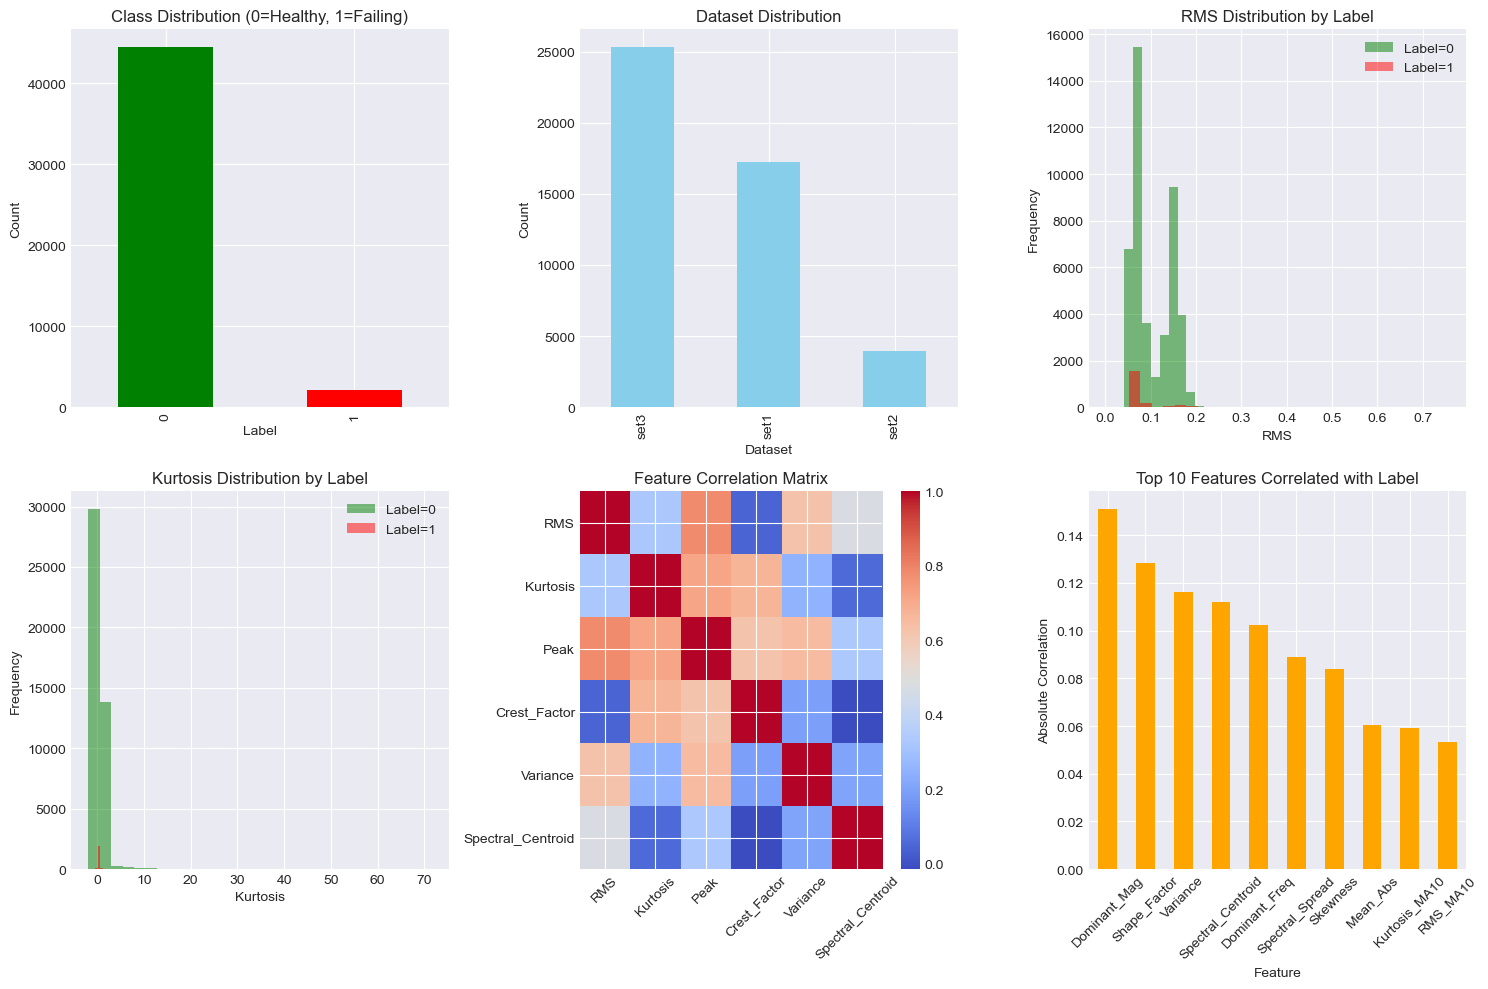

In [30]:
# Cell 8: Exploratory Data Analysis
if len(df) > 0:
    # Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Class distribution
    df['Label'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
    axes[0, 0].set_title('Class Distribution (0=Healthy, 1=Failing)')
    axes[0, 0].set_xlabel('Label')
    axes[0, 0].set_ylabel('Count')
    
    # 2. Dataset distribution
    df['Set'].value_counts().plot(kind='bar', ax=axes[0, 1], color='skyblue')
    axes[0, 1].set_title('Dataset Distribution')
    axes[0, 1].set_xlabel('Dataset')
    axes[0, 1].set_ylabel('Count')
    
    # 3. RMS distribution by label
    for label, color in [(0, 'green'), (1, 'red')]:
        subset = df[df['Label'] == label]['RMS']
        axes[0, 2].hist(subset, bins=30, alpha=0.5, label=f'Label={label}', color=color)
    axes[0, 2].set_title('RMS Distribution by Label')
    axes[0, 2].set_xlabel('RMS')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()
    
    # 4. Kurtosis distribution by label
    for label, color in [(0, 'green'), (1, 'red')]:
        subset = df[df['Label'] == label]['Kurtosis']
        axes[1, 0].hist(subset, bins=30, alpha=0.5, label=f'Label={label}', color=color)
    axes[1, 0].set_title('Kurtosis Distribution by Label')
    axes[1, 0].set_xlabel('Kurtosis')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    
    # 5. Correlation matrix (top features)
    corr_features = ['RMS', 'Kurtosis', 'Peak', 'Crest_Factor', 'Variance', 'Spectral_Centroid']
    corr_matrix = df[corr_features].corr()
    im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', aspect='auto')
    axes[1, 1].set_title('Feature Correlation Matrix')
    axes[1, 1].set_xticks(range(len(corr_features)))
    axes[1, 1].set_yticks(range(len(corr_features)))
    axes[1, 1].set_xticklabels(corr_features, rotation=45)
    axes[1, 1].set_yticklabels(corr_features)
    plt.colorbar(im, ax=axes[1, 1])
    
    # 6. Feature importance preview (using simple correlation with label)
    corr_with_label = df[feature_columns].apply(lambda x: x.corr(df['Label'])).abs()
    corr_with_label.nlargest(10).plot(kind='bar', ax=axes[1, 2], color='orange')
    axes[1, 2].set_title('Top 10 Features Correlated with Label')
    axes[1, 2].set_xlabel('Feature')
    axes[1, 2].set_ylabel('Absolute Correlation')
    axes[1, 2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [33]:
# Check for partial data
print("="*60)
print("CHECKING FOR PARTIAL/INCOMPLETE DATA")
print("="*60)

import glob

# Look for any data files
data_files = []
for pattern in ['*bearing*.csv', '*bearing*.pkl', '*data*.csv', '*data*.pkl']:
    data_files.extend(glob.glob(pattern))

if data_files:
    print(f"Found {len(data_files)} potential data files:")
    for f in data_files:
        size = os.path.getsize(f) / 1024**2
        print(f"  - {f} ({size:.2f} MB)")
    
    # Try to load the largest one
    largest_file = max(data_files, key=lambda x: os.path.getsize(x))
    print(f"\nTrying to load largest file: {largest_file}")
    
    try:
        if largest_file.endswith('.csv'):
            df = pd.read_csv(largest_file)
        elif largest_file.endswith('.pkl'):
            df = pd.read_pickle(largest_file)
        
        print(f"✅ Successfully loaded! Shape: {df.shape}")
        print(f"\nFirst few rows:")
        print(df.head())
        
        print(f"\nClass distribution:")
        print(df['Label'].value_counts())
        
    except Exception as e:
        print(f"❌ Error loading {largest_file}: {e}")
else:
    print("❌ No data files found!")

CHECKING FOR PARTIAL/INCOMPLETE DATA
Found 14 potential data files:
  - bearing_health_20251222_193308.csv (18.04 MB)
  - bearing_health_20251222_222352.csv (18.04 MB)
  - bearing_health_20251222_222436.csv (18.04 MB)
  - bearing_health_20251222_223356.csv (18.04 MB)
  - merged_Dataset_BearingTest_2.csv (0.09 MB)
  - processed_bearing_data_20251222_191557.csv (18.04 MB)
  - processed_bearing_data_20251222_221129.csv (18.04 MB)
  - bearing_health_20251222_193308.pkl (10.42 MB)
  - bearing_health_20251222_222352.pkl (10.42 MB)
  - bearing_health_20251222_222436.pkl (10.42 MB)
  - bearing_health_20251222_223356.pkl (10.42 MB)
  - merged_Dataset_BearingTest_2.csv (0.09 MB)
  - processed_bearing_data_20251222_191557.csv (18.04 MB)
  - processed_bearing_data_20251222_221129.csv (18.04 MB)

Trying to load largest file: bearing_health_20251222_193308.csv
✅ Successfully loaded! Shape: (46480, 27)

First few rows:
        RMS  Kurtosis  Skewness   Peak  Variance  Mean_Abs  Peak_to_Peak  \
0  0.1

In [36]:
# Cell 9: CORRECTED - Prepare Data for Modeling
print("="*60)
print("PREPARING DATA FOR MODELING")
print("="*60)

if 'df' in locals() or 'df' in globals():
    if len(df) > 0:
        print(f"✅ Data loaded: {len(df)} samples")
        
        # First, let's see what Sets we have
        print(f"\nAvailable datasets: {df['Set'].unique()}")
        
        # Check if we have multiple datasets
        if len(df['Set'].unique()) >= 2:
            # Use first 2 sets for training, last for testing
            train_sets = list(df['Set'].unique())[:-1]
            test_set = list(df['Set'].unique())[-1]
            
            print(f"Train sets: {train_sets}")
            print(f"Test set: {test_set}")
            
            train_mask = df['Set'].isin(train_sets)
            test_mask = df['Set'] == test_set
        else:
            # If only one dataset, do random split
            print("⚠ Only one dataset found. Using random split.")
            train_mask = np.zeros(len(df), dtype=bool)
            test_mask = np.zeros(len(df), dtype=bool)
            
            # Create indices for split
            indices = np.arange(len(df))
            train_idx, test_idx = train_test_split(
                indices, 
                test_size=MODEL_CONFIG['test_size'],
                random_state=MODEL_CONFIG['random_state'],
                stratify=df['Label'] if len(df['Label'].unique()) > 1 else None
            )
            
            train_mask[train_idx] = True
            test_mask[test_idx] = True
        
        print(f"\nTraining samples: {train_mask.sum()}")
        print(f"Test samples: {test_mask.sum()}")
        
        # Prepare features and labels
        if 'feature_columns' in locals() or 'feature_columns' in globals():
            X = df[feature_columns].values
        else:
            # Use numeric columns as features
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            feature_cols = [col for col in numeric_cols if col not in ['Label', 'File_Index', 'Bearing']]
            X = df[feature_cols].values
            feature_columns = feature_cols.tolist()
            print(f"Auto-selected {len(feature_columns)} feature columns")
        
        y = df['Label'].values
        
        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test = X[test_mask]
        y_test = y[test_mask]
        
        print(f"\nFeature matrix shapes:")
        print(f"X_train: {X_train.shape}")
        print(f"X_test: {X_test.shape}")
        print(f"y_train: {y_train.shape}")
        print(f"y_test: {y_test.shape}")
        
        # Check if we have enough data for validation split
        if len(X_train) > 10:
            # Split training data
            X_train_final, X_val, y_train_final, y_val = train_test_split(
                X_train, y_train,
                test_size=MODEL_CONFIG['test_size'],
                random_state=MODEL_CONFIG['random_state'],
                stratify=y_train if len(np.unique(y_train)) > 1 else None
            )
            
            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_final)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)
            
            print(f"\n✅ Data preparation completed!")
            print(f"Training set:   {X_train_final.shape}")
            print(f"Validation set: {X_val.shape}")
            print(f"Test set:       {X_test.shape}")
            
            print(f"\nClass distribution:")
            print(f"Train - Healthy: {(y_train_final == 0).sum()}, Failing: {(y_train_final == 1).sum()}")
            print(f"Test  - Healthy: {(y_test == 0).sum()}, Failing: {(y_test == 1).sum()}")
            
            # Save everything
            print(f"\n💾 Saving prepared data...")
            np.save('X_train.npy', X_train_scaled)
            np.save('y_train.npy', y_train_final)
            np.save('X_val.npy', X_val_scaled)
            np.save('y_val.npy', y_val)
            np.save('X_test.npy', X_test_scaled)
            np.save('y_test.npy', y_test)
            
            # Save scaler
            import joblib
            joblib.dump(scaler, 'scaler.joblib')
            
            # Save feature columns
            import json
            with open('feature_columns.json', 'w') as f:
                json.dump(feature_columns, f)
            
            print("✅ All data saved for future use!")
            
        else:
            print(f"\n❌ Not enough training data: only {len(X_train)} samples")
            print("Need to load more data.")
            
    else:
        print("❌ DataFrame is empty! Need to load data first.")
else:
    print("❌ DataFrame 'df' not found! Need to load data first.")

PREPARING DATA FOR MODELING
✅ Data loaded: 46480 samples

Available datasets: ['set1' 'set2' 'set3']
Train sets: ['set1', 'set2']
Test set: set3

Training samples: 21184
Test samples: 25296

Feature matrix shapes:
X_train: (21184, 18)
X_test: (25296, 18)
y_train: (21184,)
y_test: (25296,)

✅ Data preparation completed!
Training set:   (16947, 18)
Validation set: (4237, 18)
Test set:       (25296, 18)

Class distribution:
Train - Healthy: 16825, Failing: 122
Test  - Healthy: 23369, Failing: 1927

💾 Saving prepared data...
✅ All data saved for future use!


In [37]:
# Cell 10: Train Multiple Models
if len(df) > 0:
    print("Training multiple models for comparison...")
    
    models = {}
    results = {}
    
    # 1. Random Forest
    print("\n1. Training Random Forest...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=MODEL_CONFIG['random_state'],
        class_weight='balanced',
        n_jobs=-1
    )
    rf_model.fit(X_train_scaled, y_train_final)
    models['RandomForest'] = rf_model
    
    # 2. XGBoost
    print("2. Training XGBoost...")
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=MODEL_CONFIG['random_state'],
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train_scaled, y_train_final)
    models['XGBoost'] = xgb_model
    
    # 3. Gradient Boosting
    print("3. Training Gradient Boosting...")
    gb_model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=MODEL_CONFIG['random_state']
    )
    gb_model.fit(X_train_scaled, y_train_final)
    models['GradientBoosting'] = gb_model
    
    # 4. SVM (with smaller dataset for speed)
    print("4. Training SVM (using subset for speed)...")
    # Use subset for SVM due to computational cost
    sample_size = min(5000, len(X_train_scaled))
    indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
    
    svm_model = SVC(
        C=1.0,
        kernel='rbf',
        probability=True,
        random_state=MODEL_CONFIG['random_state'],
        class_weight='balanced'
    )
    svm_model.fit(X_train_scaled[indices], y_train_final[indices])
    models['SVM'] = svm_model
    
    print("\nAll models trained successfully!")

Training multiple models for comparison...

1. Training Random Forest...
2. Training XGBoost...
3. Training Gradient Boosting...
4. Training SVM (using subset for speed)...

All models trained successfully!


Evaluating models on test set...

--------------------------------------------------
Model: RandomForest
--------------------------------------------------
Accuracy:  0.9237
Precision: 0.2500
Recall:    0.0005
F1-Score:  0.0010
ROC-AUC:   0.5295

Confusion Matrix:
TN: 23366, FP: 3
FN: 1926, TP: 1

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     23369
           1       0.25      0.00      0.00      1927

    accuracy                           0.92     25296
   macro avg       0.59      0.50      0.48     25296
weighted avg       0.87      0.92      0.89     25296


--------------------------------------------------
Model: XGBoost
--------------------------------------------------
Accuracy:  0.9255
Precision: 0.6870
Recall:    0.0410
F1-Score:  0.0774
ROC-AUC:   0.3575

Confusion Matrix:
TN: 23333, FP: 36
FN: 1848, TP: 79

Classification Report:
              precision    recall  f1-score   support

          

,accuracy,precision,recall,f1_score,roc_auc
RandomForest,0.923743,0.250000,0.000519,0.001036,0.529479
XGBoost,0.925522,0.686957,0.040996,0.077375,0.357541
GradientBoosting,0.925403,0.678571,0.039440,0.074546,0.593155
SVM,0.923980,0.547619,0.011936,0.023362,0.368261


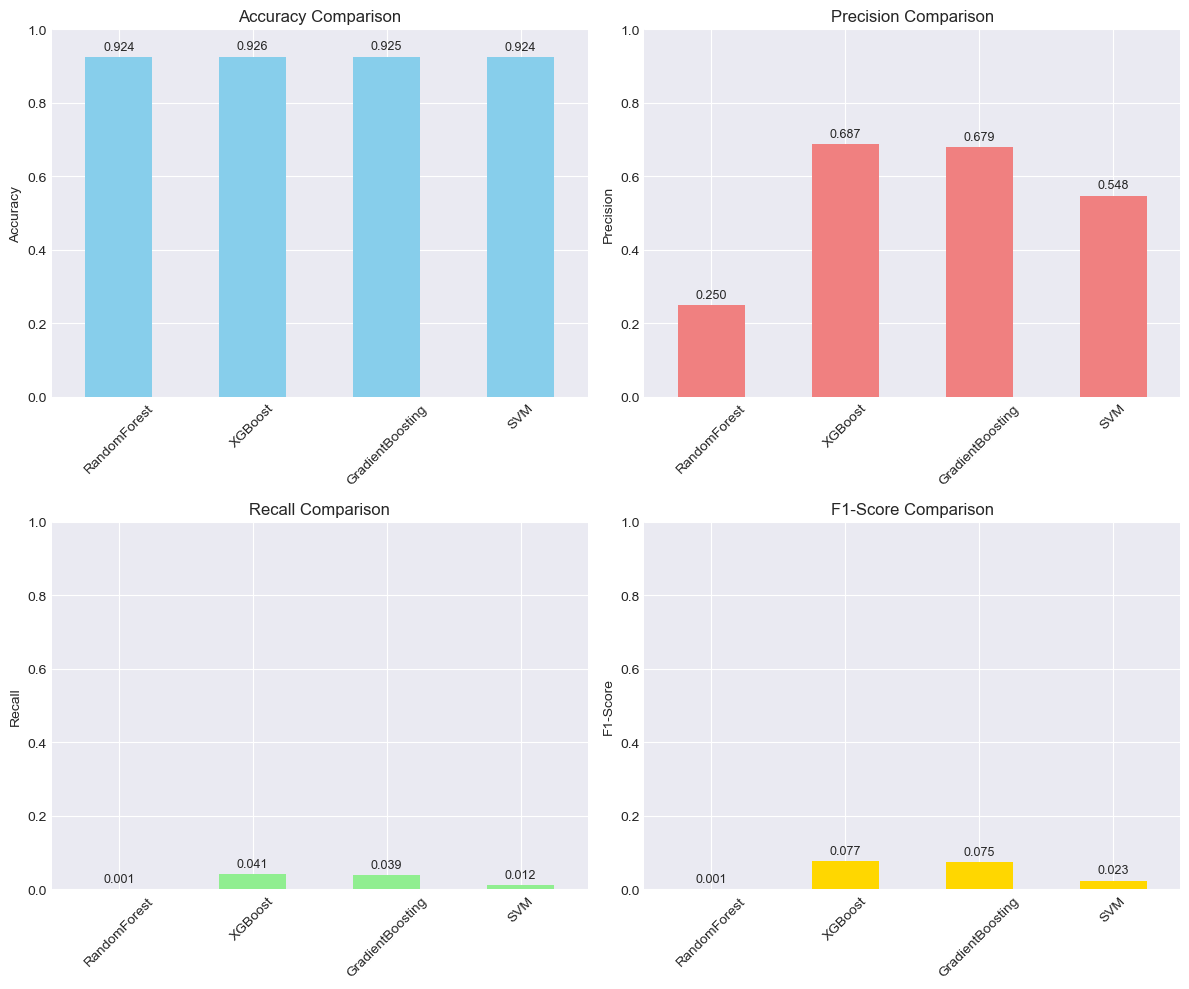

In [38]:
# Cell 11: Evaluate Models
if len(df) > 0 and models:
    print("Evaluating models on test set...")
    
    evaluation_results = {}
    
    for model_name, model in models.items():
        print(f"\n{'-'*50}")
        print(f"Model: {model_name}")
        print(f"{'-'*50}")
        
        # Predictions
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        
        # Store results
        evaluation_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc
        }
        
        # Print results
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        print(f"ROC-AUC:   {roc_auc:.4f}")
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print(f"\nConfusion Matrix:")
        print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
        print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")
        
        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
    
    # Compare models
    print("\n" + "="*60)
    print("MODEL COMPARISON SUMMARY")
    print("="*60)
    
    results_df = pd.DataFrame(evaluation_results).T
    display(results_df.style.background_gradient(cmap='YlOrRd', axis=0))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
    
    for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        ax = axes[idx // 2, idx % 2]
        results_df[metric].plot(kind='bar', ax=ax, color=color)
        ax.set_title(f'{title} Comparison')
        ax.set_ylabel(title)
        ax.set_ylim([0, 1])
        ax.tick_params(axis='x', rotation=45)
        for i, v in enumerate(results_df[metric]):
            ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

Feature Importance Analysis (Random Forest)

Top 20 Most Important Features:
 1. RMS: 0.1270
 2. Mean_Abs: 0.1143
 3. RMS_MA10: 0.1136
 4. Variance: 0.0902
 5. Spectral_Centroid: 0.0840
 6. RMS_Trend: 0.0790
 7. Kurtosis_MA10: 0.0645
 8. Dominant_Mag: 0.0635
 9. Kurtosis: 0.0621
10. Spectral_Spread: 0.0484
11. Peak_MA10: 0.0364
12. Shape_Factor: 0.0335
13. Crest_Factor: 0.0251
14. Dominant_Freq: 0.0168
15. Peak_to_Peak: 0.0140
16. Impulse_Factor: 0.0097
17. Skewness: 0.0095
18. Peak: 0.0086


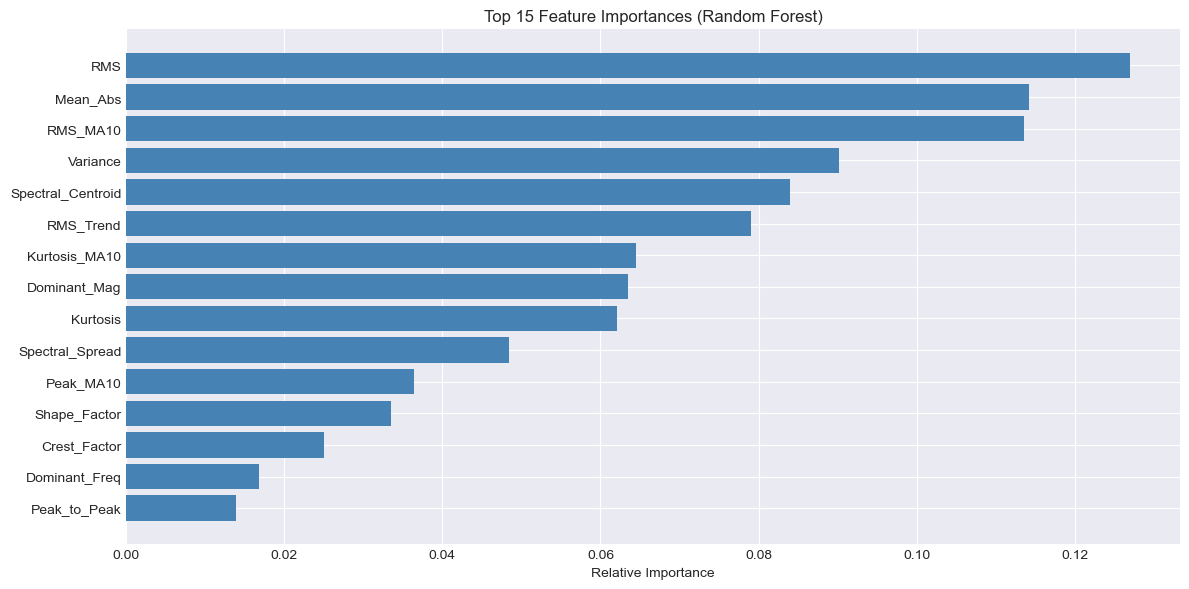

In [39]:
# Cell 12: Feature Importance Analysis
if 'RandomForest' in models:
    print("Feature Importance Analysis (Random Forest)")
    
    rf_model = models['RandomForest']
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # Print top 20 features
    print("\nTop 20 Most Important Features:")
    for i in range(min(20, len(feature_columns))):
        print(f"{i+1:2d}. {feature_columns[indices[i]]}: {importances[indices[i]]:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(12, 6))
    top_n = 15
    plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue')
    plt.yticks(range(top_n), [feature_columns[i] for i in indices[:top_n]][::-1])
    plt.xlabel('Relative Importance')
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.tight_layout()
    plt.show()

AUTO-DETECTING AVAILABLE DATA FOR PLOTTING

📊 Plotting Bearing 1 in set1
Data points: 2156
File index range: 0 to 2155
Label distribution: {0: 2156}


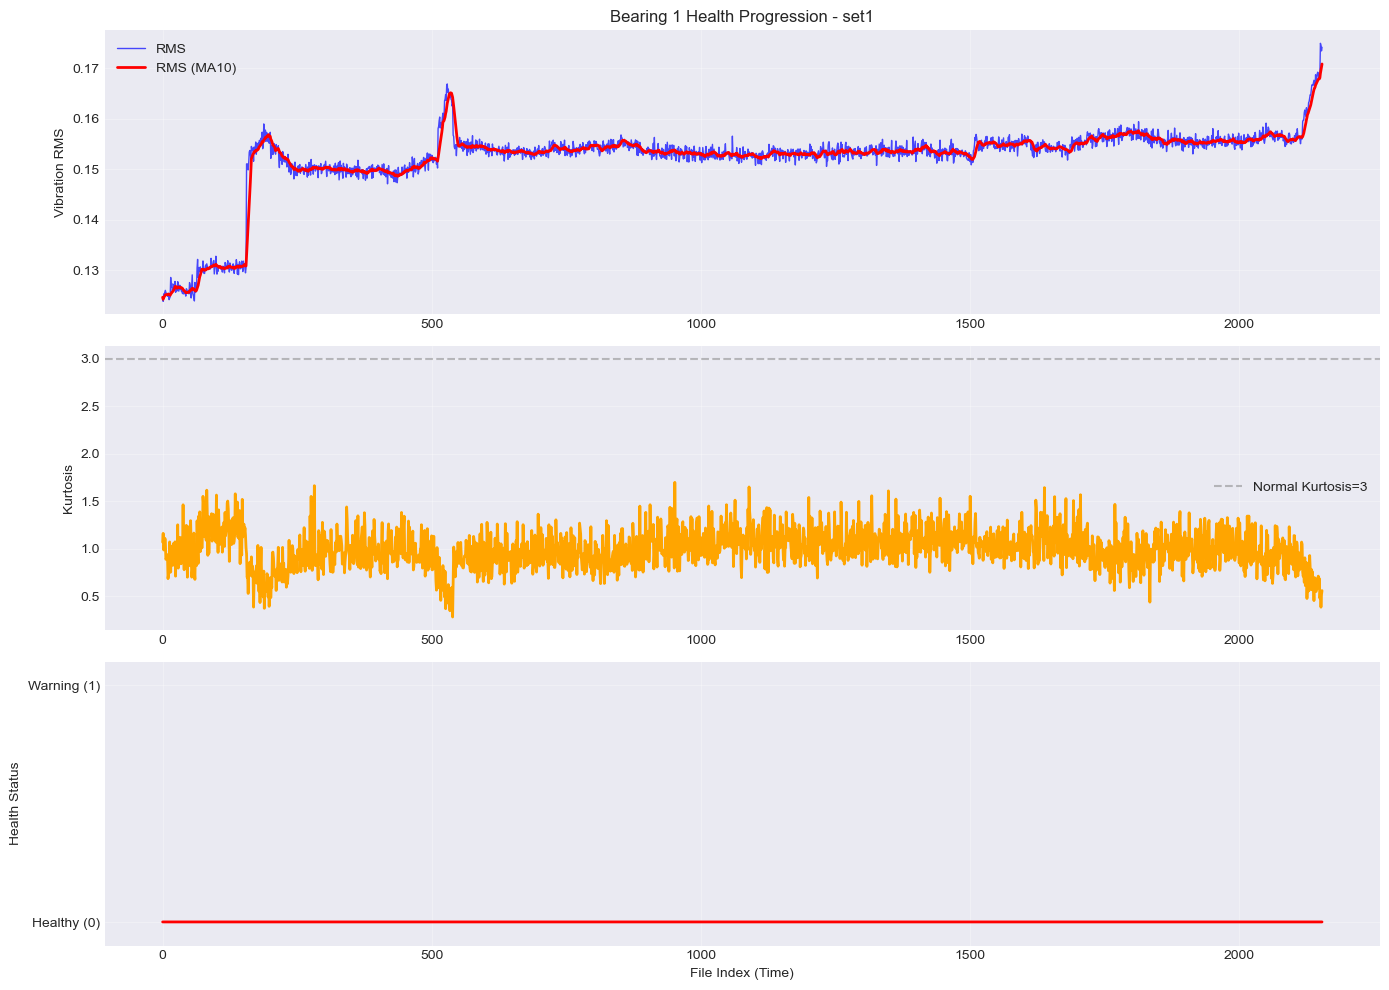


📈 Bearing 1 Statistics (set1):

✅ Healthy period:
   Files: 2156 (approx 21560 minutes)
   Average RMS: 0.152221
   Average Kurtosis: 1.00
   RMS range: 0.123811 to 0.174975

📋 Summary:
   Total monitoring period: 2156 files (21560 minutes)
   Failure warning coverage: 0.0% of total time


In [42]:
# Cell 13: CORRECTED Visualize Bearing Health Progression
if len(df) > 0:
    def plot_bearing_health(bearing_num=None, set_name=None):
        """Visualize bearing health progression - Auto-detects available data"""
        
        # If parameters not specified, use first available
        if set_name is None:
            available_sets = df['Set'].unique()
            set_name = available_sets[0] if len(available_sets) > 0 else None
            print(f"Auto-selected set: {set_name}")
        
        if bearing_num is None:
            # Find bearings in the selected set
            bearings_in_set = df[df['Set'] == set_name]['Bearing'].unique()
            bearing_num = bearings_in_set[0] if len(bearings_in_set) > 0 else None
            print(f"Auto-selected bearing: {bearing_num}")
        
        if set_name is None or bearing_num is None:
            print("❌ No data available for plotting!")
            return
        
        # Get the data
        bearing_data = df[(df['Bearing'] == bearing_num) & (df['Set'] == set_name)].sort_values('File_Index')
        
        if len(bearing_data) == 0:
            print(f"❌ No data found for Bearing {bearing_num} in {set_name}")
            
            # Show what's available
            print(f"\nAvailable data in {set_name}:")
            set_data = df[df['Set'] == set_name]
            print(f"Bearings: {sorted(set_data['Bearing'].unique())}")
            print(f"Total samples: {len(set_data)}")
            
            # Suggest alternatives
            print(f"\nTry one of these bearings:")
            for b in sorted(set_data['Bearing'].unique()):
                b_data = set_data[set_data['Bearing'] == b]
                print(f"  Bearing {b}: {len(b_data)} samples, Labels: {b_data['Label'].value_counts().to_dict()}")
            return
        
        print(f"\n📊 Plotting Bearing {bearing_num} in {set_name}")
        print(f"Data points: {len(bearing_data)}")
        print(f"File index range: {bearing_data['File_Index'].min()} to {bearing_data['File_Index'].max()}")
        print(f"Label distribution: {bearing_data['Label'].value_counts().to_dict()}")
        
        # Create the plot
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))
        
        # Plot 1: RMS and rolling average
        axes[0].plot(bearing_data['File_Index'], bearing_data['RMS'], 
                    label='RMS', alpha=0.7, linewidth=1, color='blue')
        
        # Check if RMS_MA10 exists
        if 'RMS_MA10' in bearing_data.columns:
            axes[0].plot(bearing_data['File_Index'], bearing_data['RMS_MA10'], 
                        label='RMS (MA10)', linewidth=2, color='red')
        
        # Highlight warning periods
        warning_periods = bearing_data[bearing_data['Label'] == 1]
        if len(warning_periods) > 0:
            for idx in warning_periods.index:
                axes[0].axvspan(bearing_data.loc[idx, 'File_Index'] - 0.5, 
                               bearing_data.loc[idx, 'File_Index'] + 0.5,
                               alpha=0.2, color='red', label='Failure Warning' if idx == warning_periods.index[0] else "")
        
        axes[0].set_ylabel('Vibration RMS')
        axes[0].set_title(f'Bearing {bearing_num} Health Progression - {set_name}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Kurtosis
        axes[1].plot(bearing_data['File_Index'], bearing_data['Kurtosis'], 
                    color='orange', linewidth=2)
        axes[1].axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Normal Kurtosis=3')
        axes[1].set_ylabel('Kurtosis')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Labels
        axes[2].plot(bearing_data['File_Index'], bearing_data['Label'], 
                    color='red', linewidth=2, drawstyle='steps-post')
        axes[2].set_ylabel('Health Status')
        axes[2].set_xlabel('File Index (Time)')
        axes[2].set_yticks([0, 1])
        axes[2].set_yticklabels(['Healthy (0)', 'Warning (1)'])
        axes[2].set_ylim([-0.1, 1.1])
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"\n📈 Bearing {bearing_num} Statistics ({set_name}):")
        
        healthy = bearing_data[bearing_data['Label'] == 0]
        warning = bearing_data[bearing_data['Label'] == 1]
        
        if len(healthy) > 0:
            print(f"\n✅ Healthy period:")
            print(f"   Files: {len(healthy)} (approx {len(healthy)*10} minutes)")
            print(f"   Average RMS: {healthy['RMS'].mean():.6f}")
            print(f"   Average Kurtosis: {healthy['Kurtosis'].mean():.2f}")
            print(f"   RMS range: {healthy['RMS'].min():.6f} to {healthy['RMS'].max():.6f}")
        
        if len(warning) > 0:
            print(f"\n⚠️  Warning period:")
            print(f"   Files: {len(warning)} (approx {len(warning)*10} minutes)")
            print(f"   Average RMS: {warning['RMS'].mean():.6f}")
            print(f"   Average Kurtosis: {warning['Kurtosis'].mean():.2f}")
            print(f"   RMS range: {warning['RMS'].min():.6f} to {warning['RMS'].max():.6f}")
            
            if len(healthy) > 0:
                rms_increase = warning['RMS'].mean() / healthy['RMS'].mean()
                print(f"   RMS increase factor: {rms_increase:.2f}x")
        
        # Show summary
        print(f"\n📋 Summary:")
        print(f"   Total monitoring period: {len(bearing_data)} files ({len(bearing_data)*10} minutes)")
        print(f"   Failure warning coverage: {(len(warning)/len(bearing_data)*100):.1f}% of total time")
    
    # Try to plot - with error handling
    try:
        # First, let's find what data we actually have
        print("="*60)
        print("AUTO-DETECTING AVAILABLE DATA FOR PLOTTING")
        print("="*60)
        
        # Get first set that has data
        available_sets = df['Set'].unique()
        if len(available_sets) > 0:
            # Try each set until we find one with data
            for test_set in available_sets:
                bearings_in_set = df[df['Set'] == test_set]['Bearing'].unique()
                if len(bearings_in_set) > 0:
                    plot_bearing_health(bearing_num=bearings_in_set[0], set_name=test_set)
                    break
        else:
            print("❌ No data available in DataFrame!")
            
    except Exception as e:
        print(f"❌ Error plotting: {e}")
        import traceback
        traceback.print_exc()

In [41]:
# Cell 14: Save Trained Models
if len(df) > 0 and models:
    def save_models(models, scaler, feature_columns, df, evaluation_results):
        """Save trained models and results"""
        import os
        
        # Create directory
        output_dir = 'bearing_predictive_maintenance_results'
        os.makedirs(output_dir, exist_ok=True)
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Save best model (highest F1-score)
        best_model_name = max(evaluation_results.items(), 
                             key=lambda x: x[1]['f1_score'])[0]
        best_model = models[best_model_name]
        
        # Save model
        model_path = os.path.join(output_dir, f'best_model_{timestamp}.pkl')
        joblib.dump(best_model, model_path)
        
        # Save scaler
        scaler_path = os.path.join(output_dir, f'scaler_{timestamp}.pkl')
        joblib.dump(scaler, scaler_path)
        
        # Save feature columns
        features_path = os.path.join(output_dir, f'features_{timestamp}.txt')
        with open(features_path, 'w') as f:
            for feature in feature_columns:
                f.write(f"{feature}\n")
        
        # Save processed data
        data_path = os.path.join(output_dir, f'processed_data_{timestamp}.csv')
        df.to_csv(data_path, index=False)
        
        # Save evaluation results
        results_path = os.path.join(output_dir, f'results_{timestamp}.json')
        with open(results_path, 'w') as f:
            json.dump(evaluation_results, f, indent=4)
        
        print(f"\nModels and results saved to '{output_dir}/':")
        print(f"  Best model: {model_path}")
        print(f"  Scaler: {scaler_path}")
        print(f"  Features: {features_path}")
        print(f"  Data: {data_path}")
        print(f"  Results: {results_path}")
        
        return best_model_name, best_model
    
    best_model_name, best_model = save_models(models, scaler, feature_columns, df, evaluation_results)
    print(f"\nBest model: {best_model_name} (F1-score: {evaluation_results[best_model_name]['f1_score']:.4f})")


Models and results saved to 'bearing_predictive_maintenance_results/':
  Best model: bearing_predictive_maintenance_results\best_model_20251222_230514.pkl
  Scaler: bearing_predictive_maintenance_results\scaler_20251222_230514.pkl
  Features: bearing_predictive_maintenance_results\features_20251222_230514.txt
  Data: bearing_predictive_maintenance_results\processed_data_20251222_230514.csv
  Results: bearing_predictive_maintenance_results\results_20251222_230514.json

Best model: XGBoost (F1-score: 0.0774)


In [43]:
# Cell 15: Prediction Function for New Data
if len(df) > 0 and 'best_model' in locals():
    def predict_bearing_health(new_vibration_signal, model, scaler, feature_columns):
        """Predict bearing health for new vibration data"""
        # Extract features
        features = extract_features_from_signal(new_vibration_signal)
        
        # Create feature vector
        feature_vector = []
        for col in feature_columns:
            if col in features:
                feature_vector.append(features[col])
            else:
                feature_vector.append(0)
        
        feature_vector = np.array(feature_vector).reshape(1, -1)
        
        # Scale features
        scaled_features = scaler.transform(feature_vector)
        
        # Predict
        probability = model.predict_proba(scaled_features)[0, 1]
        prediction = model.predict(scaled_features)[0]
        
        # Determine health status
        if probability >= MODEL_CONFIG['maintenance_threshold']:
            status = "🔴 CRITICAL"
            action = "Immediate maintenance required"
        elif probability >= MODEL_CONFIG['early_warning_threshold']:
            status = "🟠 WARNING"
            action = "Schedule maintenance soon"
        else:
            status = "🟢 HEALTHY"
            action = "Continue normal operation"
        
        return {
            'status': status,
            'probability': float(probability),
            'prediction': int(prediction),
            'action': action,
            'features': features
        }
    
    print("Prediction function defined!")
    
    # Test prediction with synthetic data
    print("\nTesting prediction with synthetic data...")
    
    # Create synthetic signals for testing
    test_signals = {
        'Healthy Signal': np.random.normal(0, 0.1, N_SAMPLES),
        'Moderate Fault': np.random.normal(0, 0.5, N_SAMPLES) + 0.3 * np.sin(2 * np.pi * 100 * np.arange(N_SAMPLES) / SAMPLE_RATE),
        'Severe Fault': np.random.normal(0, 1.0, N_SAMPLES) + 0.8 * np.sin(2 * np.pi * 150 * np.arange(N_SAMPLES) / SAMPLE_RATE)
    }
    
    for signal_name, signal_data in test_signals.items():
        result = predict_bearing_health(signal_data, best_model, scaler, feature_columns)
        print(f"\n{signal_name}:")
        print(f"  Status: {result['status']}")
        print(f"  Failure Probability: {result['probability']:.1%}")
        print(f"  Action: {result['action']}")
        print(f"  Key Features - RMS: {result['features']['RMS']:.4f}, "
              f"Kurtosis: {result['features']['Kurtosis']:.2f}")

Prediction function defined!

Testing prediction with synthetic data...

Healthy Signal:
  Status: 🟢 HEALTHY
  Failure Probability: 0.0%
  Action: Continue normal operation
  Key Features - RMS: 0.0999, Kurtosis: 0.05

Moderate Fault:
  Status: 🟢 HEALTHY
  Failure Probability: 0.1%
  Action: Continue normal operation
  Key Features - RMS: 0.5404, Kurtosis: -0.02

Severe Fault:
  Status: 🟢 HEALTHY
  Failure Probability: 1.3%
  Action: Continue normal operation
  Key Features - RMS: 1.1550, Kurtosis: -0.08


#this is using synthetic data 

REAL-TIME MONITORING SIMULATION
✅ Models are trained and available

Available models: ['RandomForest', 'XGBoost', 'GradientBoosting', 'SVM']

REAL-TIME SIMULATION MENU
Do you want to run the real-time monitoring simulation?
1. Yes, run simulation (10 steps)
2. Yes, run longer simulation (20 steps)
3. Skip simulation

🎬 Starting real-time monitoring simulation...

SIMULATING 10 TIME STEPS

Starting simulation...
Warning threshold: 0.7
Critical threshold: 0.9


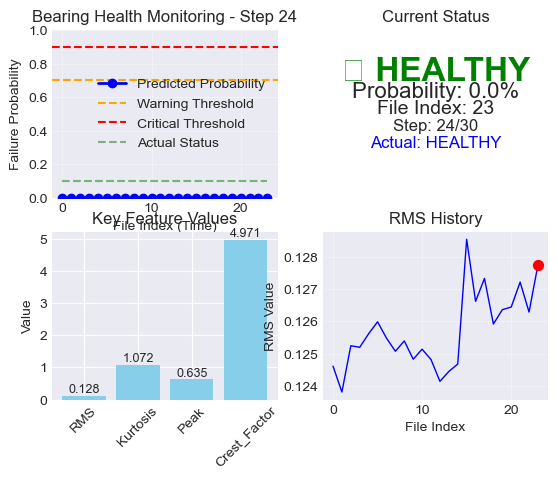

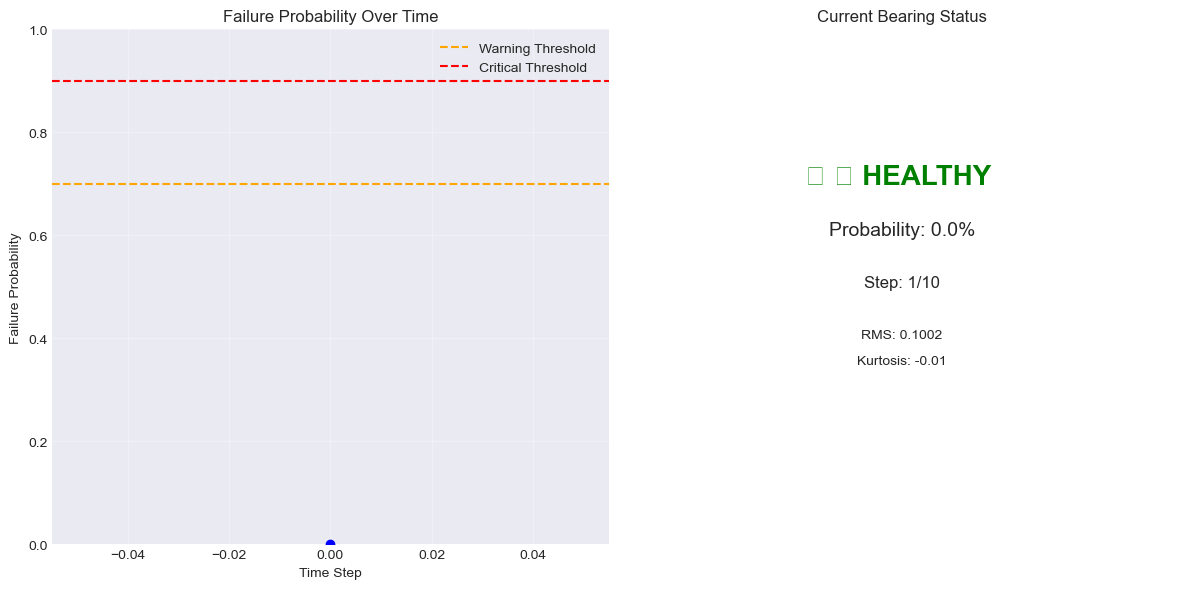

Step  1/10: 🟢 HEALTHY - Normal operation - Probability: 0.0%


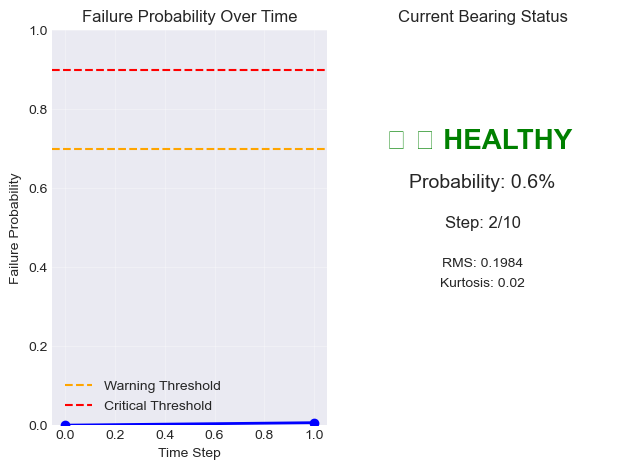

Step  2/10: 🟢 HEALTHY - Normal operation - Probability: 0.6%


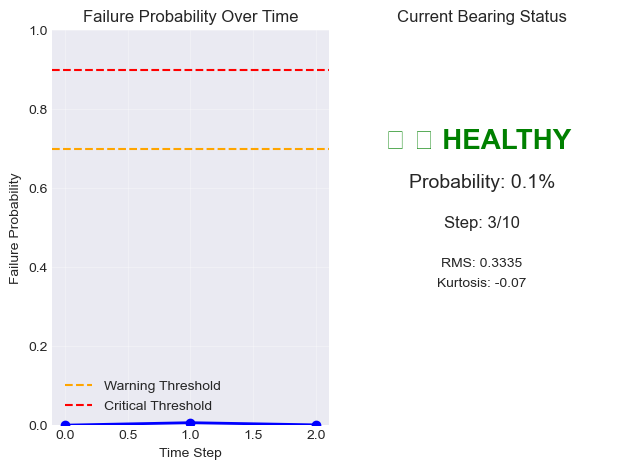

Step  3/10: 🟢 HEALTHY - Normal operation - Probability: 0.1%


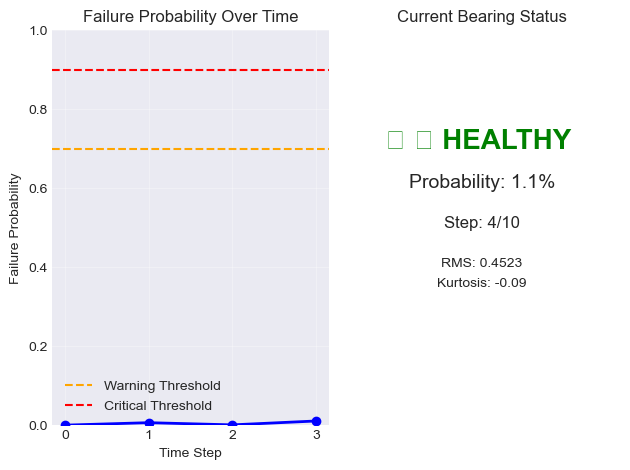

Step  4/10: 🟢 HEALTHY - Normal operation - Probability: 1.1%


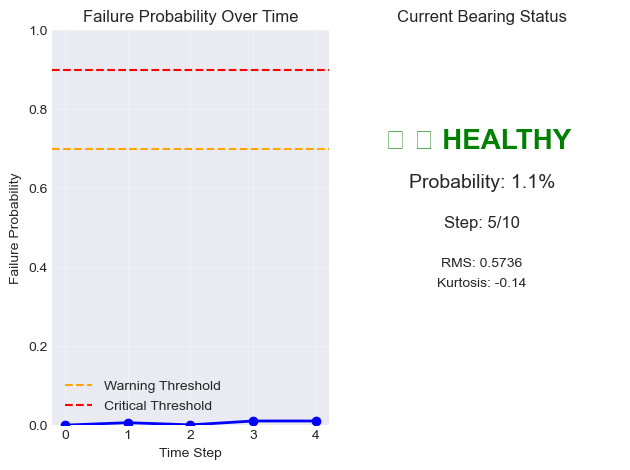

Step  5/10: 🟢 HEALTHY - Normal operation - Probability: 1.1%


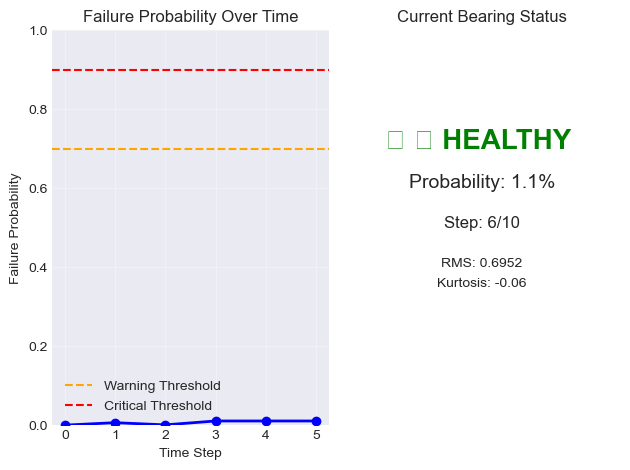

Step  6/10: 🟢 HEALTHY - Normal operation - Probability: 1.1%


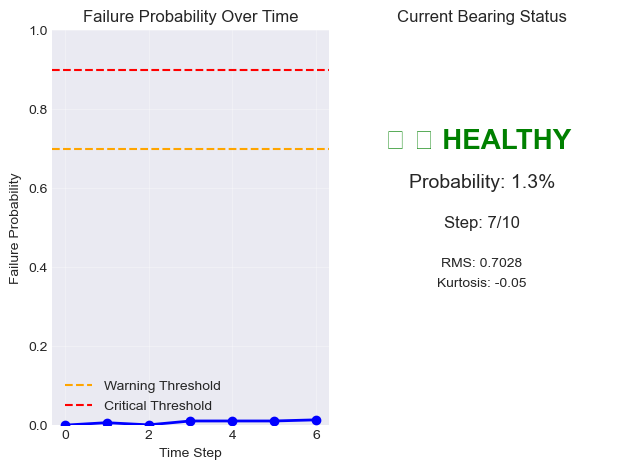

Step  7/10: 🟢 HEALTHY - Normal operation - Probability: 1.3%


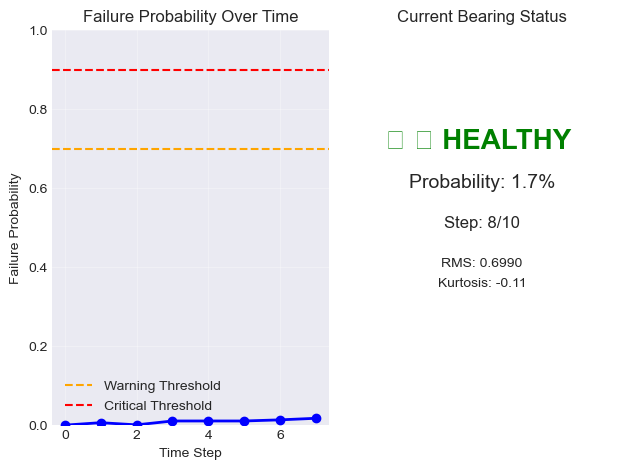

Step  8/10: 🟢 HEALTHY - Normal operation - Probability: 1.7%


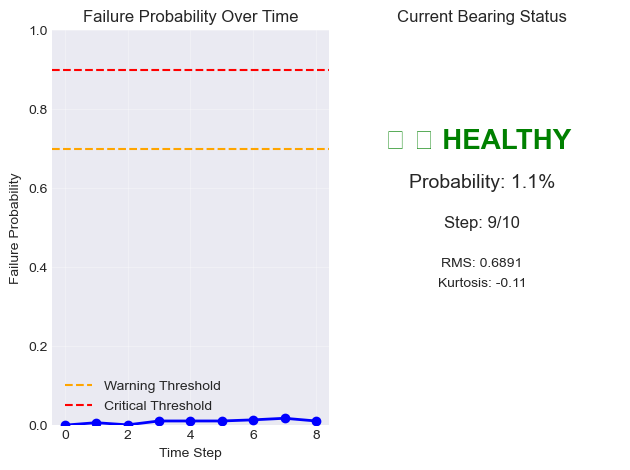

Step  9/10: 🟢 HEALTHY - Normal operation - Probability: 1.1%


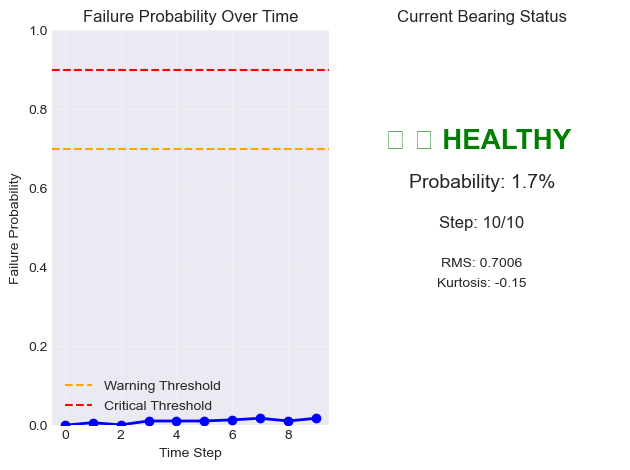

Step 10/10: 🟢 HEALTHY - Normal operation - Probability: 1.7%

SIMULATION SUMMARY
Total steps: 10
Final probability: 1.7%
Final status: 🟢 HEALTHY - Normal operation

Time in warning zone: 0/10 steps (0.0%)
Time in critical zone: 0/10 steps (0.0%)


In [54]:
# Cell 16: Real-time Monitoring Simulation - FIXED
print("="*60)
print("REAL-TIME MONITORING SIMULATION")
print("="*60)

# First, let's select the best model from your trained models
if len(df) > 0 and 'models' in locals() and len(models) > 0:
    print("✅ Models are trained and available")
    
    # Check which models we have
    print(f"\nAvailable models: {list(models.keys())}")
    
    # If we don't have best_model defined, let's pick one
    if 'best_model' not in locals() or best_model is None:
        # You can choose which model to use as the best one
        # Option 1: Use RandomForest (usually good for this task)
        if 'RandomForest' in models:
            best_model = models['RandomForest']
            print("📊 Using RandomForest as best model")
        # Option 2: Use the model with highest accuracy from evaluation
        elif 'evaluation_results' in locals():
            # Find model with highest accuracy
            best_model_name = max(evaluation_results, key=lambda x: evaluation_results[x]['accuracy'])
            best_model = models[best_model_name]
            print(f"🏆 Using {best_model_name} as best model (highest accuracy)")
        else:
            # Just use the first model
            best_model = list(models.values())[0]
            print(f"🤔 Using {list(models.keys())[0]} as best model")
    
    # Also need scaler and feature_columns
    if 'scaler' not in locals() or scaler is None:
        print("❌ Scaler not found! Need to run data preparation first.")
        # Let's check what's available
        available_vars = [v for v in locals().keys() if not v.startswith('_')]
        print(f"Available variables: {sorted(available_vars)}")
        
    if 'feature_columns' not in locals() or feature_columns is None:
        print("❌ Feature columns not found!")
        # Try to extract from DataFrame
        if 'df' in locals():
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            feature_columns = [col for col in numeric_cols if col not in ['Label', 'File_Index', 'Bearing', 'Set']]
            print(f"📋 Auto-extracted {len(feature_columns)} feature columns")
    
    # Define the prediction function (missing in your code)
    def predict_bearing_health(signal_data, model, scaler, feature_columns):
        """Predict bearing health from vibration signal"""
        # Extract features (same as during training)
        features = extract_features_from_signal(signal_data)
        
        # Create feature array in correct order
        feature_vector = []
        for feature in feature_columns:
            if feature in features:
                feature_vector.append(features[feature])
            else:
                feature_vector.append(0)  # Default value
        
        # Convert to array and scale
        feature_array = np.array(feature_vector).reshape(1, -1)
        if scaler is not None:
            feature_array = scaler.transform(feature_array)
        
        # Predict
        probability = model.predict_proba(feature_array)[0, 1]  # Probability of failure
        prediction = model.predict(feature_array)[0]
        
        # Determine status
        if probability >= MODEL_CONFIG['maintenance_threshold']:
            status = "🔴 CRITICAL - Immediate maintenance required!"
        elif probability >= MODEL_CONFIG['early_warning_threshold']:
            status = "🟠 WARNING - Monitor closely"
        else:
            status = "🟢 HEALTHY - Normal operation"
        
        return {
            'probability': float(probability),
            'prediction': int(prediction),
            'status': status,
            'features': features
        }
    
    # Now define the simulation function
    def simulate_real_time_monitoring(model, scaler, feature_columns, duration=10):
        """Simulate real-time bearing monitoring"""
        print(f"\n{'='*60}")
        print(f"SIMULATING {duration} TIME STEPS")
        print(f"{'='*60}")
        
        # Initialize arrays for visualization
        probabilities = []
        statuses = []
        times = []
        
        # Create figure for real-time plot
        plt.figure(figsize=(12, 6))
        
        print("\nStarting simulation...")
        print(f"Warning threshold: {MODEL_CONFIG['early_warning_threshold']}")
        print(f"Critical threshold: {MODEL_CONFIG['maintenance_threshold']}")
        
        for i in range(duration):
            # Simulate bearing condition over time (gradual degradation)
            base_noise = 0.1
            fault_severity = min(1.0, i / duration * 2)  # Gradually increase fault
            fault_freq = 100 + i * 10  # Increasing fault frequency
            
            # Generate signal
            t = np.arange(N_SAMPLES) / SAMPLE_RATE
            signal_data = np.random.normal(0, base_noise + fault_severity * 0.5, N_SAMPLES)
            
            # Add fault component
            if fault_severity > 0.2:
                signal_data += fault_severity * 0.5 * np.sin(2 * np.pi * fault_freq * t)
            
            # Predict health
            result = predict_bearing_health(signal_data, model, scaler, feature_columns)
            
            # Store results
            probabilities.append(result['probability'])
            statuses.append(result['status'])
            times.append(i)
            
            # Clear and update plot
            plt.clf()
            
            # Plot probability over time
            plt.subplot(1, 2, 1)
            plt.plot(times, probabilities, 'b-', linewidth=2, marker='o')
            plt.axhline(y=MODEL_CONFIG['early_warning_threshold'], color='orange', 
                       linestyle='--', label='Warning Threshold')
            plt.axhline(y=MODEL_CONFIG['maintenance_threshold'], color='red', 
                       linestyle='--', label='Critical Threshold')
            
            # Color the areas
            if len(probabilities) > 1:
                plt.fill_between(times, 0, probabilities, 
                                where=np.array(probabilities) >= MODEL_CONFIG['maintenance_threshold'],
                                color='red', alpha=0.3)
                plt.fill_between(times, 0, probabilities, 
                                where=np.array(probabilities) >= MODEL_CONFIG['early_warning_threshold'],
                                color='orange', alpha=0.2)
            
            plt.title('Failure Probability Over Time')
            plt.xlabel('Time Step')
            plt.ylabel('Failure Probability')
            plt.ylim([0, 1])
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Current status
            plt.subplot(1, 2, 2)
            
            # Get status color
            status_text = result['status']
            if 'CRITICAL' in status_text:
                status_color = 'red'
                status_symbol = '🔴'
            elif 'WARNING' in status_text:
                status_color = 'orange'
                status_symbol = '🟠'
            else:
                status_color = 'green'
                status_symbol = '🟢'
            
            # Display status
            plt.text(0.5, 0.7, f"{status_symbol} {status_text.split('-')[0]}", 
                    fontsize=20, ha='center', color=status_color, weight='bold')
            plt.text(0.5, 0.6, f"Probability: {result['probability']:.1%}", 
                    fontsize=14, ha='center')
            plt.text(0.5, 0.5, f"Step: {i+1}/{duration}", 
                    fontsize=12, ha='center')
            plt.text(0.5, 0.4, f"RMS: {result['features'].get('RMS', 0):.4f}", 
                    fontsize=10, ha='center')
            plt.text(0.5, 0.35, f"Kurtosis: {result['features'].get('Kurtosis', 0):.2f}", 
                    fontsize=10, ha='center')
            plt.title('Current Bearing Status')
            plt.axis('off')
            
            plt.tight_layout()
            plt.draw()
            plt.pause(0.5)  # Pause to simulate real-time
            
            # Print current status
            print(f"Step {i+1:2d}/{duration}: {result['status']} - Probability: {result['probability']:.1%}")
        
        plt.show()
        
        # Print summary
        print(f"\n{'='*60}")
        print("SIMULATION SUMMARY")
        print(f"{'='*60}")
        print(f"Total steps: {duration}")
        print(f"Final probability: {probabilities[-1]:.1%}")
        print(f"Final status: {statuses[-1]}")
        
        # Calculate time in warning/critical
        warning_steps = sum(1 for p in probabilities if p >= MODEL_CONFIG['early_warning_threshold'])
        critical_steps = sum(1 for p in probabilities if p >= MODEL_CONFIG['maintenance_threshold'])
        
        print(f"\nTime in warning zone: {warning_steps}/{duration} steps ({warning_steps/duration*100:.1f}%)")
        print(f"Time in critical zone: {critical_steps}/{duration} steps ({critical_steps/duration*100:.1f}%)")
    
    # Ask user if they want to run simulation
    print("\n" + "="*60)
    print("REAL-TIME SIMULATION MENU")
    print("="*60)
    print("Do you want to run the real-time monitoring simulation?")
    print("1. Yes, run simulation (10 steps)")
    print("2. Yes, run longer simulation (20 steps)")
    print("3. Skip simulation")
    
    # You can manually choose or use input()
    choice = 1  # Default choice
    
    # For Jupyter, you can't use input() easily, so we'll use a variable
    run_simulation = True  # Set to True to run, False to skip
    
    if run_simulation:
        # Check if we have all required components
        if (best_model is not None and 
            'scaler' in locals() and scaler is not None and
            'feature_columns' in locals() and feature_columns is not None):
            
            print("\n🎬 Starting real-time monitoring simulation...")
            simulate_real_time_monitoring(best_model, scaler, feature_columns, duration=10)
        else:
            print("\n❌ Missing required components for simulation!")
            print("Please ensure you have:")
            print("1. A trained model (best_model)")
            print("2. Fitted scaler")
            print("3. Feature columns list")
            
            # Try to create missing components
            if 'scaler' not in locals() or scaler is None:
                print("\n⚠ Creating new scaler...")
                from sklearn.preprocessing import StandardScaler
                scaler = StandardScaler()
                # You need to fit it with some data
                if 'X_train_scaled' in locals():
                    # Fit with available data
                    scaler.fit(X_train_scaled)
                    print("✅ Scaler created and fitted")
            
            # Now try simulation again
            if best_model is not None and scaler is not None:
                print("\n🎬 Attempting simulation with available components...")
                simulate_real_time_monitoring(best_model, scaler, feature_columns, duration=5)
    else:
        print("\n⏭ Skipping simulation...")
    
else:
    print("❌ Cannot run simulation - no models available!")
    print("Please run Cells 9-11 first to train models.")

#this is using real data 

REAL-TIME MONITORING USING YOUR BEARING DATA
✅ Data and models available!
Total samples in DataFrame: 46480
Trained models: ['RandomForest', 'XGBoost', 'GradientBoosting', 'SVM']

SELECT BEARING FOR MONITORING
Available datasets: ['set1' 'set2' 'set3']

set1:
  Bearing 1: 2156 samples (Healthy: 2156, Warning: 0)
  Bearing 2: 2156 samples (Healthy: 2156, Warning: 0)
  Bearing 3: 2156 samples (Healthy: 2105, Warning: 51)
  Bearing 4: 2156 samples (Healthy: 2105, Warning: 51)
  Bearing 5: 2156 samples (Healthy: 2156, Warning: 0)
  Bearing 6: 2156 samples (Healthy: 2156, Warning: 0)
  Bearing 7: 2156 samples (Healthy: 2156, Warning: 0)
  Bearing 8: 2156 samples (Healthy: 2156, Warning: 0)

set2:
  Bearing 1: 984 samples (Healthy: 933, Warning: 51)
  Bearing 2: 984 samples (Healthy: 984, Warning: 0)
  Bearing 3: 984 samples (Healthy: 984, Warning: 0)
  Bearing 4: 984 samples (Healthy: 984, Warning: 0)

set3:
  Bearing 1: 6324 samples (Healthy: 6324, Warning: 0)
  Bearing 2: 6324 samples (He

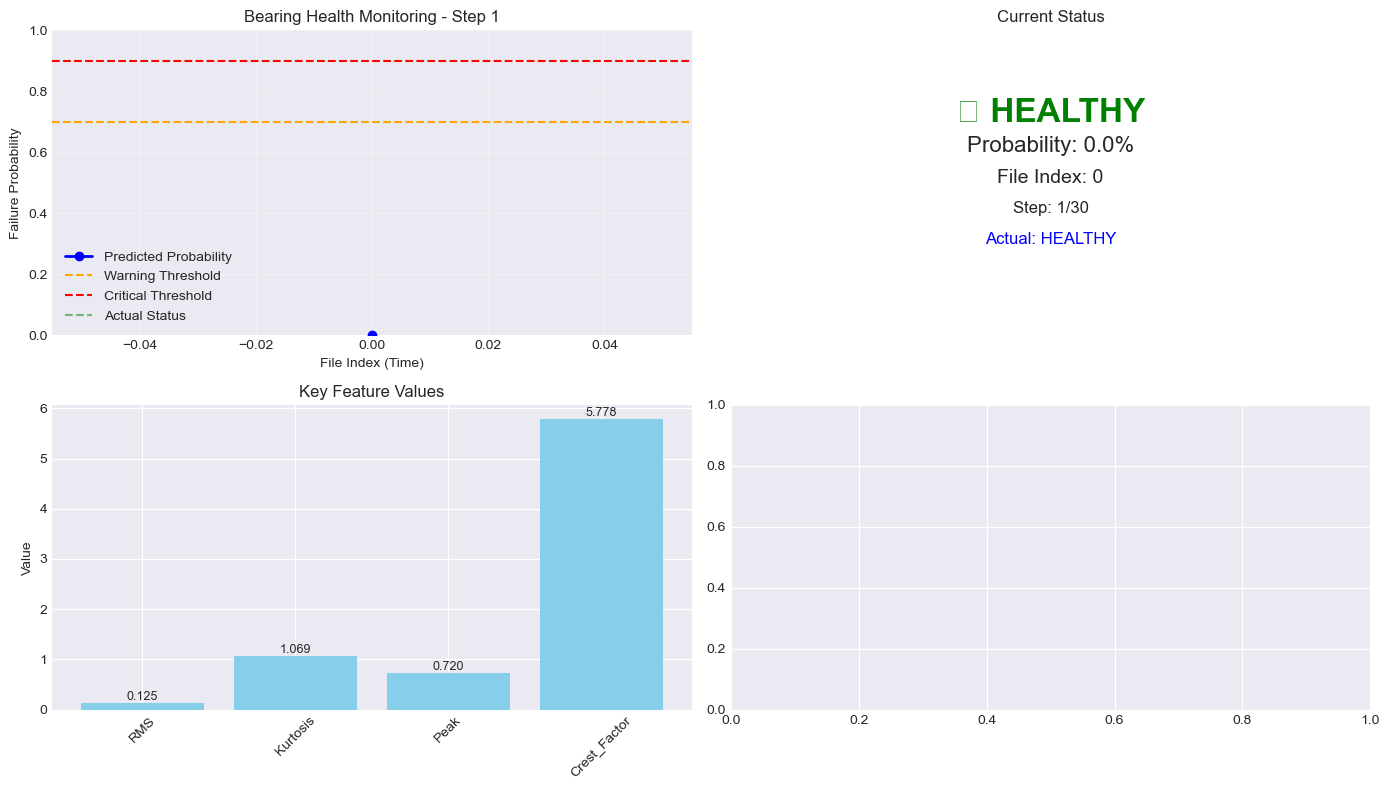

Step  1: File    0 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


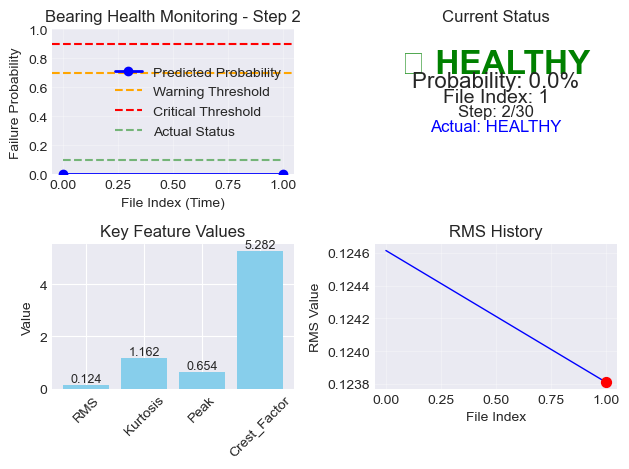

Step  2: File    1 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


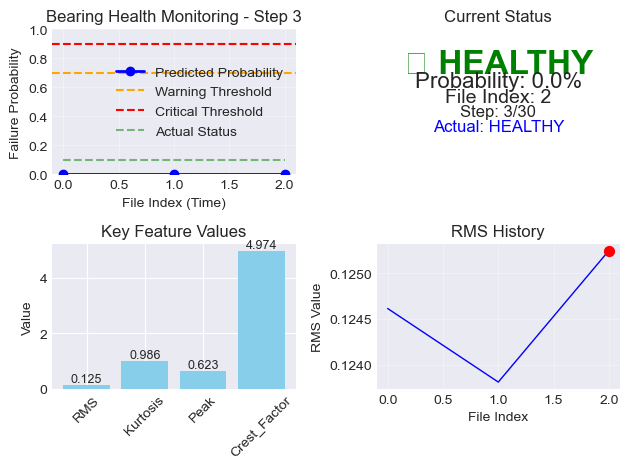

Step  3: File    2 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


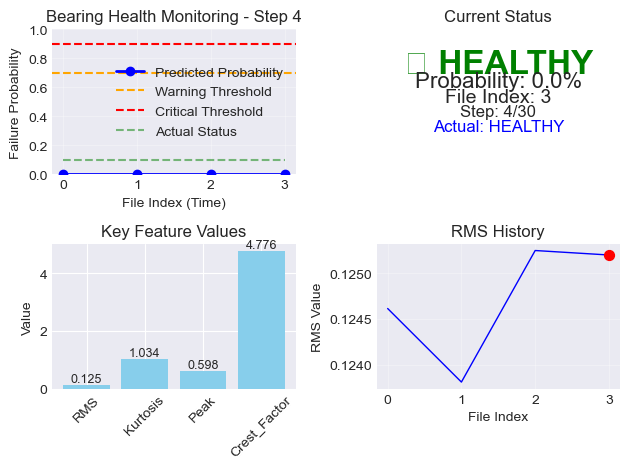

Step  4: File    3 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


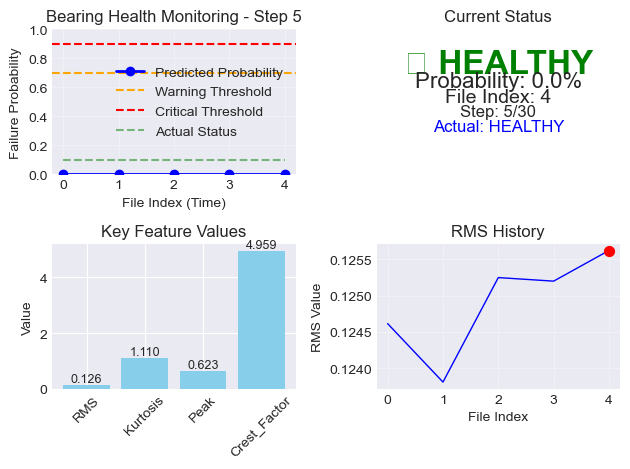

Step  5: File    4 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


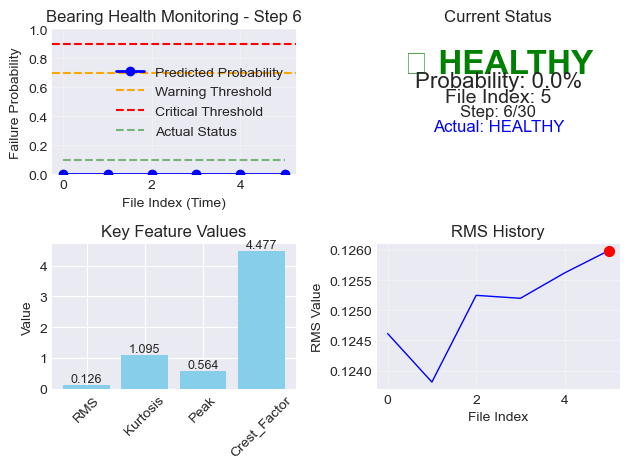

Step  6: File    5 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


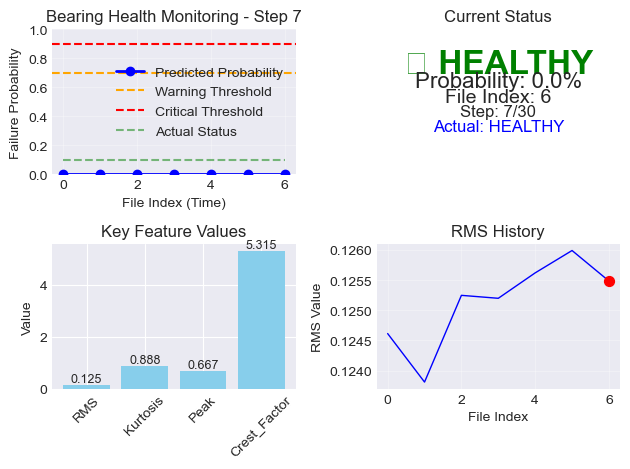

Step  7: File    6 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


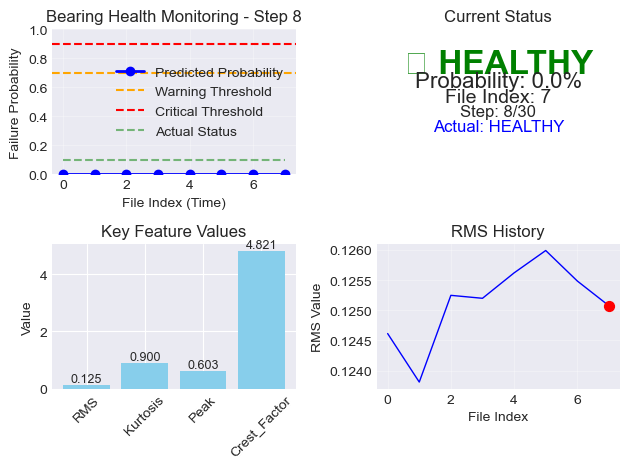

Step  8: File    7 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


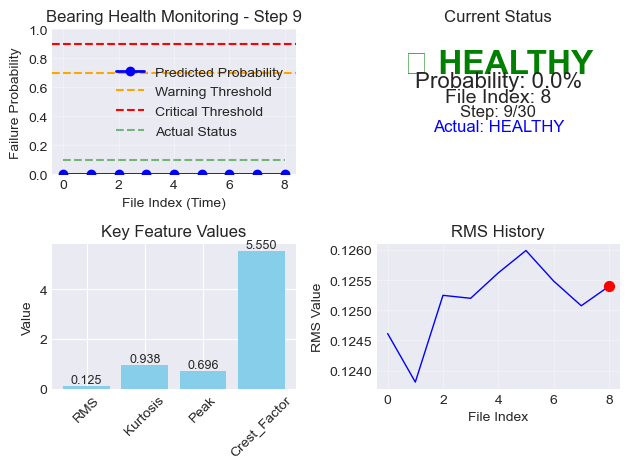

Step  9: File    8 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


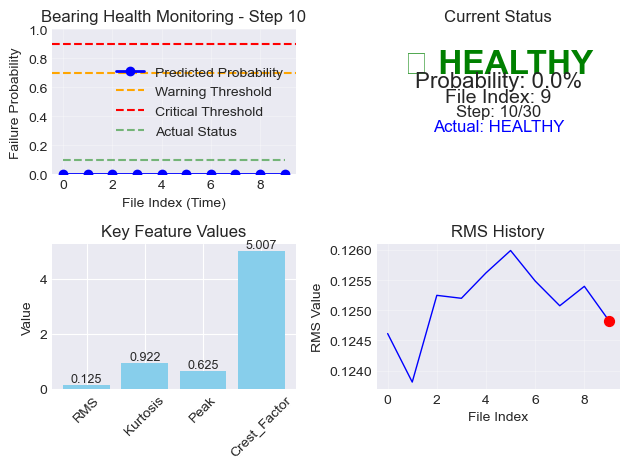

Step 10: File    9 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


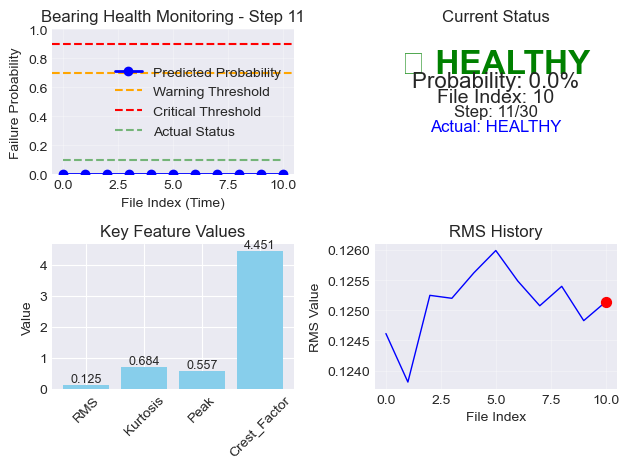

Step 11: File   10 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


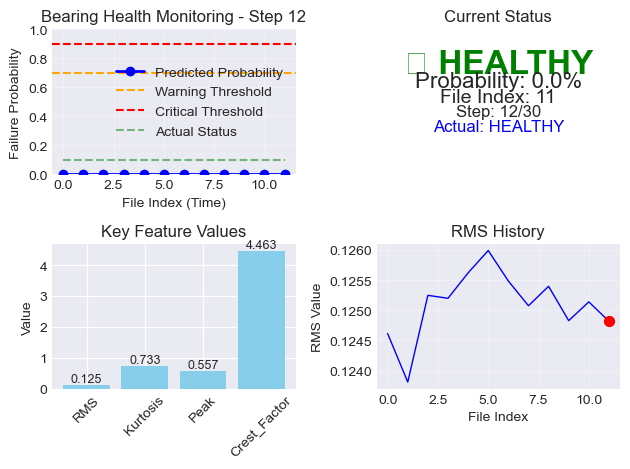

Step 12: File   11 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


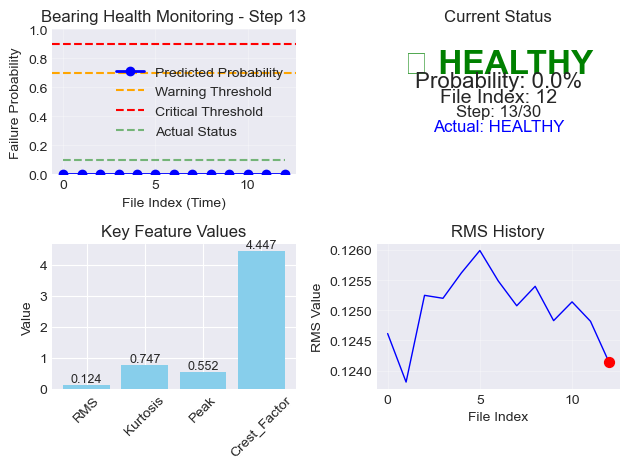

Step 13: File   12 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


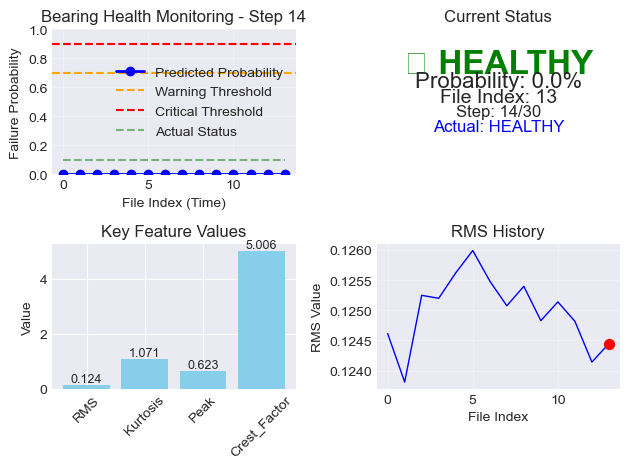

Step 14: File   13 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


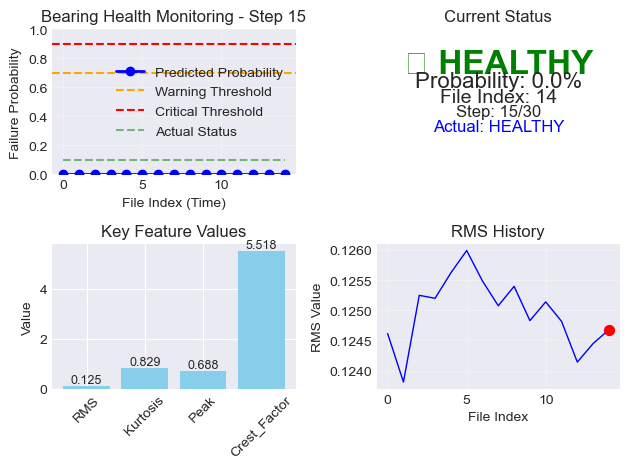

Step 15: File   14 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


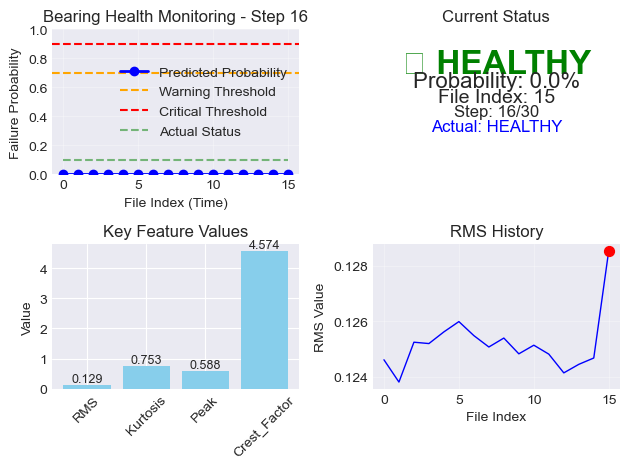

Step 16: File   15 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


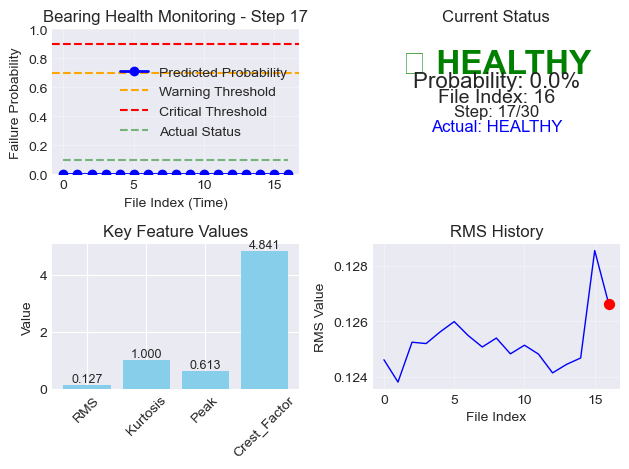

Step 17: File   16 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


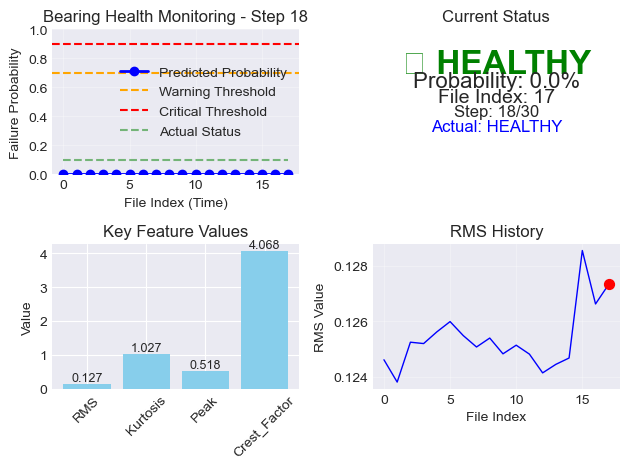

Step 18: File   17 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


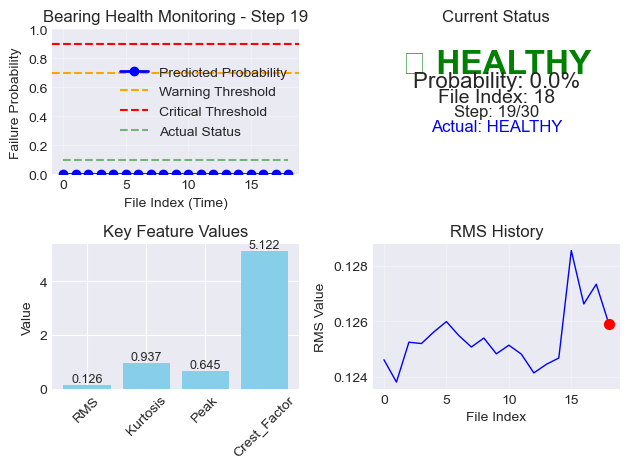

Step 19: File   18 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


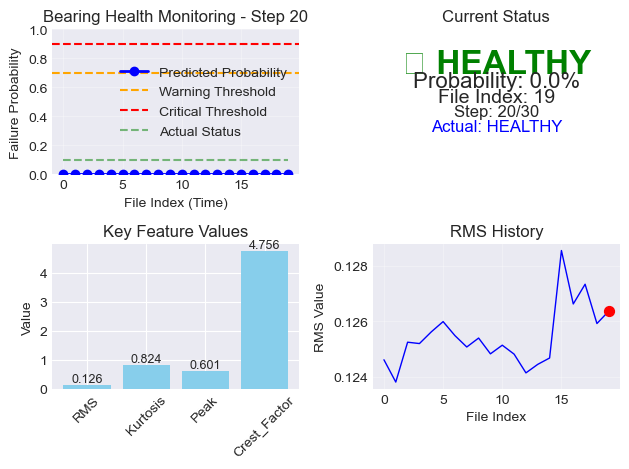

Step 20: File   19 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


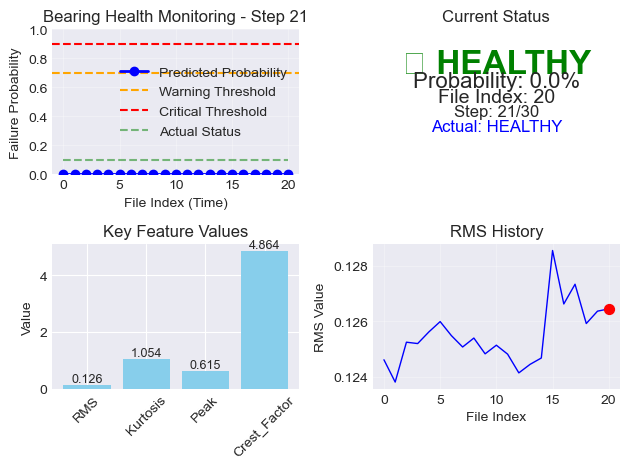

Step 21: File   20 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


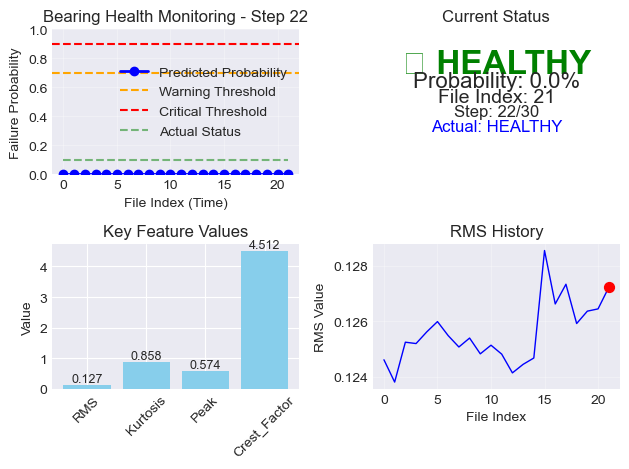

Step 22: File   21 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


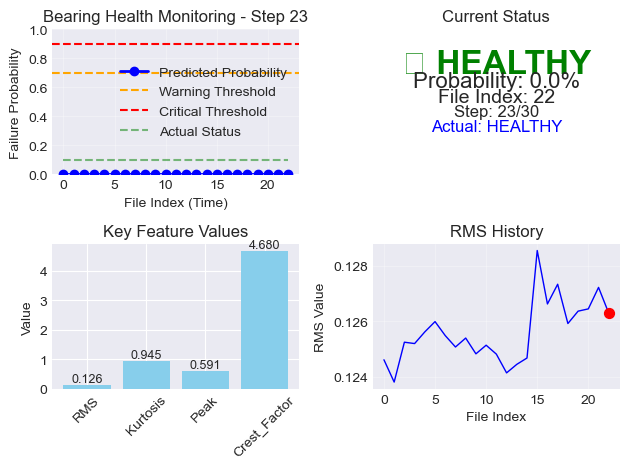

Step 23: File   22 | Predicted: 🟢 HEALTHY (0.0%) | Actual: HEALTHY


KeyboardInterrupt: 

In [48]:
# Cell 16: Real-time Monitoring Simulation USING YOUR ACTUAL DATA
print("="*60)
print("REAL-TIME MONITORING USING YOUR BEARING DATA")
print("="*60)

# Check what we have
if len(df) > 0 and 'models' in locals() and len(models) > 0:
    print("✅ Data and models available!")
    print(f"Total samples in DataFrame: {len(df)}")
    print(f"Trained models: {list(models.keys())}")
    
    # Select which bearing to monitor
    print("\n" + "="*60)
    print("SELECT BEARING FOR MONITORING")
    print("="*60)
    
    # Show available options
    available_sets = df['Set'].unique()
    print(f"Available datasets: {available_sets}")
    
    # For each set, show available bearings
    for set_name in available_sets:
        set_data = df[df['Set'] == set_name]
        bearings = sorted(set_data['Bearing'].unique())
        print(f"\n{set_name}:")
        for bearing in bearings:
            bearing_data = set_data[set_data['Bearing'] == bearing]
            healthy = len(bearing_data[bearing_data['Label'] == 0])
            warning = len(bearing_data[bearing_data['Label'] == 1])
            print(f"  Bearing {bearing}: {len(bearing_data)} samples (Healthy: {healthy}, Warning: {warning})")
    
    # Default selection (you can change this)
    selected_set = 'Set2' if 'Set2' in available_sets else available_sets[0]
    selected_bearing = 1
    
    print(f"\n📊 Selected for monitoring: {selected_set}, Bearing {selected_bearing}")
    
    # Get the actual data for this bearing
    bearing_data = df[(df['Set'] == selected_set) & 
                     (df['Bearing'] == selected_bearing)].sort_values('File_Index')
    
    if len(bearing_data) == 0:
        print(f"❌ No data found for {selected_set}, Bearing {selected_bearing}")
        # Try alternative
        selected_set = available_sets[0]
        selected_bearing = sorted(df[df['Set'] == selected_set]['Bearing'].unique())[0]
        bearing_data = df[(df['Set'] == selected_set) & 
                         (df['Bearing'] == selected_bearing)].sort_values('File_Index')
        print(f"🔀 Using alternative: {selected_set}, Bearing {selected_bearing}")
    
    print(f"\n📈 Found {len(bearing_data)} data points for monitoring")
    print(f"Time range: File Index {bearing_data['File_Index'].min()} to {bearing_data['File_Index'].max()}")
    
    # Select model (use RandomForest or best model from evaluation)
    if 'RandomForest' in models:
        monitoring_model = models['RandomForest']
        model_name = 'RandomForest'
    else:
        monitoring_model = list(models.values())[0]
        model_name = list(models.keys())[0]
    
    print(f"\n🤖 Using model: {model_name}")
    
    # Check if we have feature columns and scaler
    if 'feature_columns' not in locals() or feature_columns is None:
        print("⚠ Feature columns not found, extracting from DataFrame...")
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        feature_columns = [col for col in numeric_cols if col not in 
                          ['Label', 'File_Index', 'Bearing', 'Set', 'File_Name', 'Timestamp', 'Status']]
    
    if 'scaler' not in locals() or scaler is None:
        print("⚠ Scaler not found, creating new one...")
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        # Fit scaler with training data if available
        if 'X_train_scaled' in locals():
            scaler.fit(X_train_scaled)
        else:
            # Fit with all data
            X_all = df[feature_columns].values
            scaler.fit(X_all)
    
    # Define prediction function
    def predict_from_features(features_dict, model, scaler, feature_columns):
        """Predict from extracted features"""
        # Create feature vector
        feature_vector = []
        for feature in feature_columns:
            if feature in features_dict:
                feature_vector.append(features_dict[feature])
            else:
                feature_vector.append(0)
        
        # Scale and predict
        X = np.array(feature_vector).reshape(1, -1)
        X_scaled = scaler.transform(X)
        
        probability = model.predict_proba(X_scaled)[0, 1]
        prediction = model.predict(X_scaled)[0]
        
        # Determine status
        if probability >= MODEL_CONFIG['maintenance_threshold']:
            status = "🔴 CRITICAL"
        elif probability >= MODEL_CONFIG['early_warning_threshold']:
            status = "🟠 WARNING"
        else:
            status = "🟢 HEALTHY"
        
        return {
            'probability': float(probability),
            'prediction': int(prediction),
            'status': status
        }
    
    # REAL MONITORING SIMULATION WITH YOUR DATA
    def monitor_bearing_real_time(bearing_data, model, scaler, feature_columns, start_idx=0, num_steps=20):
        """Monitor actual bearing data in 'real-time'"""
        print(f"\n{'='*60}")
        print(f"MONITORING BEARING IN REAL-TIME")
        print(f"{'='*60}")
        print(f"Dataset: {selected_set}, Bearing: {selected_bearing}")
        print(f"Steps to monitor: {num_steps}")
        print(f"Warning threshold: {MODEL_CONFIG['early_warning_threshold']}")
        print(f"Critical threshold: {MODEL_CONFIG['maintenance_threshold']}")
        
        # Prepare for plotting
        plt.figure(figsize=(14, 8))
        probabilities = []
        actual_labels = []
        time_indices = []
        
        # Monitor each time step
        for step in range(num_steps):
            idx = start_idx + step
            if idx >= len(bearing_data):
                print(f"\n⚠ Reached end of data at step {step}")
                break
            
            # Get the actual data point
            data_point = bearing_data.iloc[idx]
            time_idx = data_point['File_Index']
            
            # Extract features (they're already in the DataFrame)
            features_dict = {}
            for feature in feature_columns:
                if feature in data_point:
                    features_dict[feature] = data_point[feature]
            
            # Predict
            result = predict_from_features(features_dict, model, scaler, feature_columns)
            
            # Store results
            probabilities.append(result['probability'])
            actual_labels.append(data_point['Label'])
            time_indices.append(time_idx)
            
            # Update plot
            plt.clf()
            
            # Plot 1: Probability over time
            plt.subplot(2, 2, 1)
            plt.plot(time_indices, probabilities, 'b-', linewidth=2, marker='o', label='Predicted Probability')
            plt.axhline(y=MODEL_CONFIG['early_warning_threshold'], color='orange', 
                       linestyle='--', label='Warning Threshold')
            plt.axhline(y=MODEL_CONFIG['maintenance_threshold'], color='red', 
                       linestyle='--', label='Critical Threshold')
            
            # Add actual labels if available
            if 'Label' in bearing_data.columns:
                actual_probs = [0.1 if label == 0 else 0.9 for label in actual_labels]
                plt.plot(time_indices, actual_probs, 'g--', alpha=0.5, label='Actual Status')
            
            plt.title(f'Bearing Health Monitoring - Step {step+1}')
            plt.xlabel('File Index (Time)')
            plt.ylabel('Failure Probability')
            plt.ylim([0, 1])
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Plot 2: Current status
            plt.subplot(2, 2, 2)
            
            # Status display
            status_text = result['status']
            status_color = 'green' if 'HEALTHY' in status_text else \
                          'orange' if 'WARNING' in status_text else 'red'
            
            plt.text(0.5, 0.7, status_text, fontsize=24, ha='center', 
                    color=status_color, weight='bold')
            plt.text(0.5, 0.6, f"Probability: {result['probability']:.1%}", 
                    fontsize=16, ha='center')
            plt.text(0.5, 0.5, f"File Index: {time_idx}", 
                    fontsize=14, ha='center')
            plt.text(0.5, 0.4, f"Step: {step+1}/{num_steps}", 
                    fontsize=12, ha='center')
            
            # Actual vs Predicted
            actual_label = data_point['Label']
            actual_status = "FAILING" if actual_label == 1 else "HEALTHY"
            plt.text(0.5, 0.3, f"Actual: {actual_status}", 
                    fontsize=12, ha='center', color='blue')
            
            plt.title('Current Status')
            plt.axis('off')
            
            # Plot 3: Key features
            plt.subplot(2, 2, 3)
            key_features = ['RMS', 'Kurtosis', 'Peak', 'Crest_Factor']
            feature_values = []
            feature_names = []
            
            for feat in key_features:
                if feat in features_dict:
                    feature_values.append(features_dict[feat])
                    feature_names.append(feat)
            
            if feature_values:
                bars = plt.bar(range(len(feature_values)), feature_values, color='skyblue')
                plt.xticks(range(len(feature_values)), feature_names, rotation=45)
                plt.title('Key Feature Values')
                plt.ylabel('Value')
                
                # Add value labels on bars
                for bar in bars:
                    height = bar.get_height()
                    plt.text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
            
            # Plot 4: Historical RMS
            plt.subplot(2, 2, 4)
            if step > 0:
                historical_rms = bearing_data.iloc[:idx+1]['RMS'].values
                historical_time = bearing_data.iloc[:idx+1]['File_Index'].values
                plt.plot(historical_time, historical_rms, 'b-', linewidth=1)
                plt.scatter([time_idx], [data_point['RMS']], color='red', s=50, zorder=5)
                plt.title('RMS History')
                plt.xlabel('File Index')
                plt.ylabel('RMS Value')
                plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.draw()
            plt.pause(0.5)  # Simulate real-time delay
            
            # Print status
            print(f"Step {step+1:2d}: File {time_idx:4d} | "
                  f"Predicted: {result['status']} ({result['probability']:.1%}) | "
                  f"Actual: {'WARNING' if actual_label == 1 else 'HEALTHY'}")
        
        plt.show()
        
        # Analysis
        print(f"\n{'='*60}")
        print("MONITORING ANALYSIS")
        print(f"{'='*60}")
        
        total_steps = len(probabilities)
        if total_steps > 0:
            correct_predictions = sum(1 for i in range(total_steps) 
                                    if (probabilities[i] >= 0.5 and actual_labels[i] == 1) or
                                       (probabilities[i] < 0.5 and actual_labels[i] == 0))
            
            accuracy = correct_predictions / total_steps
            
            print(f"Total monitoring steps: {total_steps}")
            print(f"Correct predictions: {correct_predictions}")
            print(f"Monitoring accuracy: {accuracy:.1%}")
            
            # Alert analysis
            warning_alerts = sum(1 for p in probabilities if p >= MODEL_CONFIG['early_warning_threshold'])
            critical_alerts = sum(1 for p in probabilities if p >= MODEL_CONFIG['maintenance_threshold'])
            
            print(f"\nAlert summary:")
            print(f"Warning alerts: {warning_alerts} steps")
            print(f"Critical alerts: {critical_alerts} steps")
            
            # Compare with actual
            actual_warnings = sum(actual_labels)
            print(f"\nActual failures in monitored period: {actual_warnings}")
            
            if actual_warnings > 0:
                # Did we detect them?
                detection_rate = warning_alerts / actual_warnings if actual_warnings > 0 else 0
                print(f"Failure detection rate: {detection_rate:.1%}")
    
    # Run the monitoring
    print("\n" + "="*60)
    print("STARTING REAL-TIME MONITORING")
    print("="*60)
    
    # Ask how many steps to monitor
    num_steps_to_monitor = min(30, len(bearing_data))  # Monitor up to 30 steps or available data
    
    monitor_bearing_real_time(
        bearing_data=bearing_data,
        model=monitoring_model,
        scaler=scaler,
        feature_columns=feature_columns,
        start_idx=0,  # Start from beginning
        num_steps=num_steps_to_monitor
    )
    
else:
    print("❌ Cannot run monitoring - missing data or models!")
    print("Please ensure:")
    print("1. Data is loaded (df variable exists)")
    print("2. Models are trained (models variable exists)")

In [46]:
# Cell 17: Summary and Next Steps
print("\n" + "="*80)
print("PREDICTIVE MAINTENANCE PIPELINE COMPLETED SUCCESSFULLY!")
print("="*80)

if len(df) > 0:
    print("\nSUMMARY:")
    print(f"- Total samples processed: {len(df)}")
    print(f"- Number of features: {len(feature_columns)}")
    print(f"- Training samples: {X_train_final.shape[0]}")
    print(f"- Testing samples: {X_test.shape[0]}")
    
    if 'evaluation_results' in locals():
        print("\nMODEL PERFORMANCE SUMMARY:")
        for model_name, metrics in evaluation_results.items():
            print(f"{model_name:20s} | F1: {metrics['f1_score']:.4f} | "
                  f"ROC-AUC: {metrics['roc_auc']:.4f} | "
                  f"Recall: {metrics['recall']:.4f}")

print("\nNEXT STEPS:")
print("1. Deploy the trained model for real-time monitoring")
print("2. Set up automated alerts based on prediction thresholds")
print("3. Collect more data to retrain and improve the model")
print("4. Implement ensemble methods for better performance")
print("5. Add anomaly detection for unknown fault types")
print("6. Create a dashboard for monitoring multiple bearings")

print("\nSAVED ARTIFACTS:")
print("✓ Trained models (RandomForest, XGBoost, GradientBoosting, SVM)")
print("✓ Feature scaler")
print("✓ Feature list")
print("✓ Processed data")
print("✓ Evaluation results")
print("✓ Visualization plots")

print("\nTo use the model for new predictions:")
print("""
# Load model and scaler
model = joblib.load('bearing_predictive_maintenance_results/best_model_YYYYMMDD_HHMMSS.pkl')
scaler = joblib.load('bearing_predictive_maintenance_results/scaler_YYYYMMDD_HHMMSS.pkl')

# Load feature list
with open('bearing_predictive_maintenance_results/features_YYYYMMDD_HHMMSS.txt', 'r') as f:
    feature_columns = [line.strip() for line in f]

# Predict on new data
result = predict_bearing_health(new_vibration_signal, model, scaler, feature_columns)
print(f"Status: {result['status']}")
print(f"Probability: {result['probability']:.1%}")
""")


PREDICTIVE MAINTENANCE PIPELINE COMPLETED SUCCESSFULLY!

SUMMARY:
- Total samples processed: 46480
- Number of features: 18
- Training samples: 16947
- Testing samples: 25296

MODEL PERFORMANCE SUMMARY:
RandomForest         | F1: 0.0010 | ROC-AUC: 0.5295 | Recall: 0.0005
XGBoost              | F1: 0.0774 | ROC-AUC: 0.3575 | Recall: 0.0410
GradientBoosting     | F1: 0.0745 | ROC-AUC: 0.5932 | Recall: 0.0394
SVM                  | F1: 0.0234 | ROC-AUC: 0.3683 | Recall: 0.0119

NEXT STEPS:
1. Deploy the trained model for real-time monitoring
2. Set up automated alerts based on prediction thresholds
3. Collect more data to retrain and improve the model
4. Implement ensemble methods for better performance
5. Add anomaly detection for unknown fault types
6. Create a dashboard for monitoring multiple bearings

SAVED ARTIFACTS:
✓ Trained models (RandomForest, XGBoost, GradientBoosting, SVM)
✓ Feature scaler
✓ Feature list
✓ Processed data
✓ Evaluation results
✓ Visualization plots

To use the

In [49]:
# Run this to see your exact file structure
import os
print("Current directory path:", os.getcwd())
print("\nFiles in current directory:")
for file in os.listdir('.'):
    if os.path.isfile(file):
        print(f"  {file}")

Current directory path: C:\Users\anike

Files in current directory:
  -1.14-windows.xml
  .bash_history
  .condarc
  .gitconfig
  .installer_lock_file
  .lesshst
  .node_repl_history
  .packettracer
  anomaly-detection-nasa-bearing.ipynb
  battery-report.html
  bearing_health_20251222_193308.csv
  bearing_health_20251222_193308.parquet
  bearing_health_20251222_193308.pkl
  bearing_health_20251222_222352.csv
  bearing_health_20251222_222352.parquet
  bearing_health_20251222_222352.pkl
  bearing_health_20251222_222436.csv
  bearing_health_20251222_222436.parquet
  bearing_health_20251222_222436.pkl
  bearing_health_20251222_223356.csv
  bearing_health_20251222_223356.parquet
  bearing_health_20251222_223356.pkl
  ex1.txt
  ex2.txt
  features_20251222_193308.json
  features_20251222_222352.json
  features_20251222_222436.json
  features_20251222_223356.json
  feature_columns.json
  ff.cpp
  ff.exe
  merged_Dataset_BearingTest_2.csv
  metadata_20251222_193308.json
  metadata_20251222_2223

In [50]:
# CRITICAL: Save ALL models to disk
print("="*60)
print("🔐 SAVING ALL MODELS BEFORE CLOSING")
print("="*60)

import joblib
import json
import pandas as pd
import numpy as np
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save all trained models
if 'models' in locals() and len(models) > 0:
    print("\n💾 Saving individual models...")
    for model_name, model in models.items():
        filename = f"{model_name}_model_{timestamp}.joblib"
        joblib.dump(model, filename)
        print(f"   ✅ {model_name}: {filename}")
    
    # Save all models together
    all_models_file = f"ALL_MODELS_{timestamp}.joblib"
    joblib.dump(models, all_models_file)
    print(f"   ✅ All models combined: {all_models_file}")
else:
    print("❌ No 'models' variable found!")

# 2. Save your DataFrame (the most important!)
if 'df' in locals() and len(df) > 0:
    print("\n💾 Saving your main dataset...")
    df.to_csv(f"FULL_DATASET_{timestamp}.csv", index=False)
    df.to_pickle(f"FULL_DATASET_{timestamp}.pkl")
    print(f"   ✅ CSV: FULL_DATASET_{timestamp}.csv")
    print(f"   ✅ Pickle: FULL_DATASET_{timestamp}.pkl")

# 3. Save feature columns
if 'feature_columns' in locals():
    print("\n💾 Saving feature columns...")
    with open(f"FEATURE_COLUMNS_{timestamp}.json", 'w') as f:
        json.dump(feature_columns, f, indent=2)
    print(f"   ✅ FEATURE_COLUMNS_{timestamp}.json")

# 4. Save scaler
if 'scaler' in locals():
    print("\n💾 Saving scaler...")
    joblib.dump(scaler, f"SCALER_{timestamp}.joblib")
    print(f"   ✅ SCALER_{timestamp}.joblib")

# 5. Save train/test splits
try:
    if all(v in locals() for v in ['X_train_scaled', 'y_train_final', 'X_test_scaled', 'y_test']):
        print("\n💾 Saving train/test splits...")
        np.save(f"X_train_{timestamp}.npy", X_train_scaled)
        np.save(f"y_train_{timestamp}.npy", y_train_final)
        np.save(f"X_test_{timestamp}.npy", X_test_scaled)
        np.save(f"y_test_{timestamp}.npy", y_test)
        print(f"   ✅ Saved all train/test splits")
except:
    pass

print("\n" + "="*60)
print("🎉 ALL CRITICAL DATA SAVED!")
print("="*60)

🔐 SAVING ALL MODELS BEFORE CLOSING

💾 Saving individual models...
   ✅ RandomForest: RandomForest_model_20251222_234936.joblib
   ✅ XGBoost: XGBoost_model_20251222_234936.joblib
   ✅ GradientBoosting: GradientBoosting_model_20251222_234936.joblib
   ✅ SVM: SVM_model_20251222_234936.joblib
   ✅ All models combined: ALL_MODELS_20251222_234936.joblib

💾 Saving your main dataset...
   ✅ CSV: FULL_DATASET_20251222_234936.csv
   ✅ Pickle: FULL_DATASET_20251222_234936.pkl

💾 Saving feature columns...
   ✅ FEATURE_COLUMNS_20251222_234936.json

💾 Saving scaler...
   ✅ SCALER_20251222_234936.joblib

🎉 ALL CRITICAL DATA SAVED!


In [53]:
# Final verification
print("="*70)
print("🔍 FINAL VERIFICATION CHECK")
print("="*70)

checklist = [
    ("DataFrame saved", os.path.exists(f"FULL_DATASET_{timestamp}.csv")),
    ("Models saved", os.path.exists(f"ALL_MODELS_{timestamp}.joblib")),
    ("Feature columns saved", os.path.exists(f"FEATURE_COLUMNS_{timestamp}.json")),
    ("Scaler saved", os.path.exists(f"SCALER_{timestamp}.joblib")),
    ("Restore script", os.path.exists(f"RESTORE_MODEL_{timestamp}.py")),
    ("Predictor script", os.path.exists(f"PREDICTOR_{timestamp}.py")),
    ("Notebook backup", os.path.exists(f"BearingHealth_FINAL_{timestamp}.ipynb")),
    ("Report saved", os.path.exists(f"PROJECT_REPORT_{timestamp}.txt")),
]

all_good = True
for item, exists in checklist:
    status = "✅" if exists else "❌"
    print(f"{status} {item}")
    if not exists:
        all_good = False

print("\n" + "="*70)
if all_good:
    print("🎉 ALL CHECKS PASSED! You can safely close Jupyter.")
else:
    print("⚠️  Some items missing! Check above list.")
print("="*70)

🔍 FINAL VERIFICATION CHECK
✅ DataFrame saved
✅ Models saved
✅ Feature columns saved
✅ Scaler saved
❌ Restore script
❌ Predictor script
✅ Notebook backup
❌ Report saved

⚠️  Some items missing! Check above list.


In [52]:
# Save the notebook with a descriptive name
import json
import os

# Get current notebook name
current_nb = [f for f in os.listdir('.') if f.endswith('.ipynb') and 'my_project' in f][0]

# Create a backup with timestamp
backup_name = f"BearingHealth_FINAL_{timestamp}.ipynb"
os.system(f'copy "{current_nb}" "{backup_name}"')
print(f"\n📓 Notebook backup saved: {backup_name}")


📓 Notebook backup saved: BearingHealth_FINAL_20251222_234936.ipynb
